<a href="https://colab.research.google.com/github/RaquelHernanz/BachelorsThesis_SyntheticClinicalData/blob/master/NOTEBOOK6_BTSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 6 — Synthetic Data Generation with CTAB-GAN+**

- **Author:** Raquel Hernanz Hernández
- **Supervisors:** José María Herrera and Guillermo José Ortega
- **Degree:** Biomedical Engineering  
- **Project:** Bachelor Thesis — *Generation and Validation of Synthetic Data from a Hospital Emergency Department*

---

## Role in the pipeline

| Notebook | Purpose |
|----------|---------|
| NB5| Pre-generation data transformations |
| **NB6 (this notebook)** | Synthetic data generation — CTAB-GAN+ |
| NB7 | Synthetic data generation — ARF/FORDE |

---

## Notebook overview

| Stage | Section | Description |
|-------|---------|-------------|
| 1 | Libraries | Package imports and environment setup |
| 2 | Configuration | Global parameters, hyperparameters, pipeline flags |
| 3 | Build four exclusive cohorts | Mort. 2D, Mort. 7D (exclusive), Mort. 30D (exclusive), Survivors |
| 4 | Train one CTAB-GAN+ per cohort | One conditional GAN generator fitted per exclusive mortality cohort |
| 5 | Draw N replicas from each fitted generator | N = 10 seeded stochastic samples drawn from each fitted generator |
| 6 | Inverse-transform to clinical scale | OHE inverse (argmax); MinMax/log1p inverse if active |
| 7 | Run a compact per-replica fidelity screening | Balanced KS (continuous) and TVD (discrete) |
| 8 | Export per replica | `dataset_SYNTH_CTABGAN.csv` |

---

## Objective

Generation of N = 10 synthetic replicas of the prehospital emergency dataset
using **CTAB-GAN+**. The notebook fits one cohort-specific generator per exclusive mortality stratum defined by cumulative outcome coding.

---

## Outputs
- `GENERATION/DATASET_CTABGAN/dsXX/…` for XX in 01–10
- `GENERATION/DATASET_CTABGAN/dataset_TEST.csv` (shared real test partition)
- `GENERATION/DATASET_CTABGAN/generation_metadata.json`
- `GENERATION/DATASET_CTABGAN/figures/fig_replicas_vs_real.png`


# **What is a Generative Adversarial Network?**

Generative Adversarial Networks (GANs) are a family of generative models designed to learn the underlying distribution of a real dataset and generate new synthetic samples that resemble it. They were originally developed in the context of deep learning and have been widely used for image generation, although later adaptations have extended their use to tabular, clinical, time-series, and other structured data.

A GAN is composed of two neural networks trained simultaneously:

- **Generator**: creates synthetic samples from random noise or latent vectors. Its objective is to produce data that look similar to the real observations.
- **Discriminator**: receives both real and synthetic samples and tries to distinguish whether each observation comes from the real dataset or from the generator.

The training process is adversarial because both networks compete against each other. The generator tries to fool the discriminator, while the discriminator tries to correctly identify fake samples. As training progresses, the generator receives feedback from the discriminator and gradually improves its ability to create realistic synthetic data.

In simplified terms, the process can be described as follows:

1. random noise is passed to the generator.
2. the generator creates synthetic observations.
3. the discriminator compares real and synthetic observations.
4. the discriminator learns to classify observations as real or synthetic.
5. the generator is updated to make its synthetic observations harder to detect.
6. the process is repeated until the synthetic data become difficult to distinguish from the real data.

For tabular healthcare data, GANs are attractive because they can learn complex nonlinear relationships between variables and generate new records that preserve some statistical patterns of the original dataset. However, applying GANs to tabular clinical data is more challenging than applying them to images. Clinical datasets often contain mixed variable types, missingness patterns, class imbalance, skewed numerical distributions, and clinically meaningful dependencies between variables.

Because of these difficulties, specialised tabular GANs have been proposed. These models modify the standard GAN architecture to better handle categorical variables, continuous variables, imbalanced distributions, and downstream machine learning utility.

# **Model selection: CTAB-GAN+ VS TT-GAN?**

**CTAB-GAN+** (from Conditional Tabular Generative Adversarial Network Plus, Zhao et al. 2023) and **TT-GAN** (from Tabular Transformer Generative Adversarial Network, Kang et al. 2025) are both conditional GAN architectures for heterogeneous tabular data, but they differ substantially in their design choices and suitability for this dataset.

**TT-GAN** operates through a three-stage pipeline:
1) *discretisation*: where continuous variables are converted to categorical variables via k-means clustering.
2) *generation*: where a Transformer encoder with multi-head attention captures
inter-column dependencies inside a GAN framework with binary cross-entropy loss.
3) *conversion*: where a tree-based regression model (RF, CatBoost, XGBoost,
or LightGBM) reconstructs the original continuous values from the discretised synthetic output.

TT-GAN was designed to handle the heterogeneous and inter-dependent nature of healthcare tabular data and demonstrated superior performance over CTGAN and CopulaGAN on lung and liver cancer datasets with several thousand records.

**CTAB-GAN+**, on the other hand, extends the CTGAN model with four components directly relevant to this dataset:

1. **Mode-Specific Normalisation (MSN/VGM)**: continuous variables are decomposed into Gaussian mixture modes and normalised per mode, enabling the generator to reproduce multimodal and long-tail clinical distributions (e.g., Lactato, Glucemia, FiO2) without requiring an external converter step. Variables following a single Gaussian distribution (e.g., Edad, TAD) are instead handled by the General Transform, a min-max scaler to [−1, 1], which bypasses VGM to avoid unnecessary mode splitting on well-behaved distributions.

2. **Wasserstein loss with gradient penalty (WGAN+GP)**: replaces binary cross-entropy with a gradient-penalised Wasserstein objective, providing more stable training dynamics by enforcing the Lipschitz constraint without weight clipping. This is particularly advantageous under the small-sample regime of the mortality cohorts (for instance `n_train = 55 or 100`), where binary cross-entropy GANs are prone to mode collapse and vanishing gradients.

3. **Auxiliary classifier (C)**: an MLP trained on real data in parallel to the discriminator that contributes a downstream loss to the generator, penalising semantically inconsistent feature combinations and enforcing coherent inter-variable correlations in the synthetic records.

4. **One-hot encoding of categorical variables**: CTAB-GAN+ applies OHE internally to all categorical variables as part of its data transformer. In this pipeline, OHE is also applied upstream in NB5 (`CFG_OHE = True`), which is the only active pre-generation transformation. This redundancy is intentional: passing OHE dummies as `categorical` columns to CTAB-GAN+ gives the model explicit column boundaries for the conditional vector and the training-by-sampling procedure, substantially improving fidelity on Ritmo and ST compared to passing raw integer codes.

> CTAB-GAN+ was preferred over TT-GAN for three main reasons. First, the discretisation and conversion pipeline of TT-GAN introduces an additional source of approximation error: the tree-based converter is trained on real data and its predictions on synthetic discretised output carry their own regression uncertainty, compounding with GAN sampling variability. Second, TT-GAN was evaluated on datasets of several thousand records; its Transformer encoder requires sufficient data to learn meaningful multi-head attention weights, whereas WGAN+GP training in CTAB-GAN+ has demonstrated enough stability on small-cohort sizes. Third, CTAB-GAN+ handles continuous, categorical, and mixed
variable types natively within a unified encoding framework without an external converter stage, which simplifies the pipeline and reduces potential transformation errors.


## **1. Libraries and environment setup**

The following libraries are required in **Section 1.1**, which installs dependencies, pins the **CTAB-GAN+** repository to a fixed commit, and records the runtime environment in `generation_metadata.json`.

| Library | Role |
|---------|------|
| `pandas`, `numpy` | Tabular data handling, numerical operations, random seed management |
| `torch` | PyTorch backend for CTAB-GAN+; controls intra-op thread count on CPU and GPU selection |
| `json` | Load and write transformation metadata (NB5 → NB6, NB6 → NB8/NB9) |
| `time` | Wall-clock profiling of fit and sampling phases |
| `platform`, `importlib.metadata` | Environment metadata: Python version, package versions, and CTAB-GAN+ commit hash |
| `multiprocessing` | Parallel cohort training on CPU (`fork`); disabled on GPU (sequential execution) |
| `sklearn.model_selection` | `train_test_split` for deterministic per-cohort partitioning |
| `scipy.stats` | `ks_2samp` for the balanced Kolmogorov–Smirnov fidelity statistic |
| `matplotlib`, `seaborn` | Distribution comparison plots (section 11); saved as PNG artefacts |
| **CTAB-GAN+** (`model.ctabgan`, `model.synthesizer.ctabgan_synthesizer`) | `CTABGAN` handles data loading, column-type configuration, and internal VGM fitting on continuous variables. `CTABGANSynthesizer` exposes the training hyperparameters (`epochs`, `batch_size`, `num_channels`, `random_dim`, `class_dim`, `l2scale`) and the `fit()` / `generate_samples()` interface used by the worker in section 7. |



In [12]:

"""
PURPOSE : Install pinned dependencies, clone CTAB-GAN+ to a fixed commit,
          and expose collect_environment_metadata() for provenance tracking.

Outputs : CTABGAN_DIR (str), CTABGAN_COMMIT_HASH (str),
          collect_environment_metadata() (callable).
"""
# ══════════════════════════════════════════════════════════════════════
# 1.1 — Install dependencies, pin CTAB-GAN+, and expose environment metadata
# ══════════════════════════════════════════════════════════════════════
import subprocess
import sys
import os
import platform
import importlib.metadata as importlib_metadata

# Detect if running in Google Colab
IS_COLAB = "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ

# Practical runtime pins.
# The official CTAB-GAN+ README lists older package versions, but modern Colab
# Python images may not support the full legacy stack. The key package required
# by this implementation is pinned; the remaining runtime versions are recorded
# in generation_metadata.json for reproducibility.
PYTHON_PACKAGE_PINS = [
    "torch>=1.9",
    "dython==0.6.4.post1",
    "scipy>=1.4",
    "scikit-learn>=0.24",
]
for dep in PYTHON_PACKAGE_PINS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", dep])

# Pin CTAB-GAN+ source code.
CTABGAN_REPO_URL = "https://github.com/Team-TUD/CTAB-GAN-Plus.git"
CTABGAN_GIT_REF = "6a6f901"  # official repo commit: correct WGAN-GP critic iteration

if IS_COLAB:
    CTABGAN_DIR = "/content/CTAB-GAN-Plus"
else:
    CTABGAN_DIR = "./CTAB-GAN-Plus"

if not os.path.isdir(os.path.join(CTABGAN_DIR, ".git")):
    subprocess.check_call(["git", "clone", CTABGAN_REPO_URL, CTABGAN_DIR])
    print(f"✓ CTAB-GAN+ cloned to {CTABGAN_DIR}")
else:
    print(f"✓ CTAB-GAN+ repository already present at {CTABGAN_DIR}")

subprocess.check_call(["git", "-C", CTABGAN_DIR, "fetch", "--all", "--tags", "--quiet"])
subprocess.check_call(["git", "-C", CTABGAN_DIR, "checkout", "--quiet", CTABGAN_GIT_REF])
CTABGAN_COMMIT_HASH = subprocess.check_output(
    ["git", "-C", CTABGAN_DIR, "rev-parse", "HEAD"],
    text=True,
).strip()
print(f"✓ CTAB-GAN+ checked out at {CTABGAN_COMMIT_HASH[:12]}")

# Add to Python path so imports resolve from the pinned checkout
if CTABGAN_DIR not in sys.path:
    sys.path.insert(0, CTABGAN_DIR)
    print(f"✓ Added {CTABGAN_DIR} to sys.path")

_PACKAGE_DISTRIBUTIONS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "dython": "dython",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

def _package_version(distribution_name: str) -> str | None:
    try:
        return importlib_metadata.version(distribution_name)
    except importlib_metadata.PackageNotFoundError:
        return None

def collect_environment_metadata() -> dict:
    """Return the runtime metadata exported with generation_metadata.json."""
    return {
        "python": sys.version.replace("\n", " "),
        "platform": platform.platform(),
        "is_colab": bool(IS_COLAB),
        "packages": {
            import_name: _package_version(dist_name)
            for import_name, dist_name in _PACKAGE_DISTRIBUTIONS.items()
        },
        "ctabgan_plus": {
            "repo_url": CTABGAN_REPO_URL,
            "git_ref_requested": CTABGAN_GIT_REF,
            "commit_hash": CTABGAN_COMMIT_HASH,
            "local_path": CTABGAN_DIR,
        },
        "pip_pins": PYTHON_PACKAGE_PINS,
    }

print("✓ Environment metadata helper ready.")


✓ CTAB-GAN+ repository already present at /content/CTAB-GAN-Plus
✓ CTAB-GAN+ checked out at 6a6f90188cca
✓ Environment metadata helper ready.


In [13]:
"""
PURPOSE : Import all libraries required by NB6.

Libraries
---------
numpy, pandas          — data handling and numerical operations.
torch                  — PyTorch backend for CTAB-GAN+.
matplotlib, seaborn    — distribution comparison plots.
CTAB-GAN+ (model.*)   — generator and synthesiser classes.
"""

from __future__ import annotations
import numpy as np
import pandas as pd
import json
import time
import warnings
import multiprocessing as mp
from typing import Dict, List
from IPython.display import display
from pathlib import Path
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# CTAB-GAN+ imports
from model.ctabgan import CTABGAN
from model.synthesizer.ctabgan_synthesizer import CTABGANSynthesizer

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device:      {torch.cuda.get_device_name(0)}")
print(f"CPU count:       {mp.cpu_count()}")
print("\nAll libraries loaded successfully.")


PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU device:      Tesla T4
CPU count:       2

All libraries loaded successfully.


### Global plot style

A unified `rcParams` dictionary (`TFG_STYLE`) is applied at the start of every
plotting notebook via `mpl.rcParams.update()` and `sns.set_theme()`. This ensures
that all figures share the same typographic and colour conventions regardless of
the order in which cells are executed.

Key design decisions:
- **Serif font** (`DejaVu Serif` / `Times New Roman`): matches the thesis document
  style and improves legibility in printed figures.
- **White background with thin grid**: avoids grey-background seaborn defaults
  that reduce contrast in greyscale prints.
- **Fixed DPI** (screen: 100, save: 150): balances render speed with export quality.
- **Shared Real / Synthetic colour pair** (`COLOUR_REAL = #3366CC` blue,
  `COLOUR_SYNTH = #d62728` red): used consistently in all distribution comparison
  plots (section 11) so that visual correspondence is immediately recognisable across figures.


In [14]:
# ── TFG Unified Plot Style ─────────────────────────────────────────────
TFG_STYLE = {
    "axes.facecolor":    "white",
    "figure.facecolor":  "white",
    "axes.edgecolor":    "black",
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "#d9d9d9",
    "grid.linewidth":    0.5,
    "grid.linestyle":    "-",
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#cccccc",
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "figure.dpi":        100,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
}
mpl.rcParams.update(TFG_STYLE)
sns.set_theme(style="white", rc=TFG_STYLE)

# ── Shared colours for Real vs Synthetic comparison ───────────────────
COLOUR_REAL  = "#3366CC"
COLOUR_SYNTH = "#d62728"

print("TFG plot style applied.")


TFG plot style applied.


## **2. Configuration**

Central parameter panel. All **CTAB-GAN+** hyperparameters and pipeline settings are defined here; downstream cells read from these variables directly.

### Execution strategy

Two execution modes are supported, resolved automatically from `torch.cuda.is_available()`:

- **GPU mode** (`USE_CUDA = True`, **standard for this version**): cohorts are trained sequentially on the GPU (T4). The validated hyperparameters in `COHORT_HP_OVERRIDES` were obtained under this mode and produce the best KS/TVD results. GPU training substantially reduces wall time (~25-30 min on GPU vs ~45+ min on CPU for 4 cohorts × 10 replicas).
- **CPU mode** (`USE_CUDA = False`): cohorts are trained employing `fork`. The CPU branch retains its own `COHORT_HP_OVERRIDES` block but requires independent re-tuning.

### Pre-generation transformations

As mentioned in **section 1**, of the available **NB5** transformations (`CFG_OHE`, `CFG_MINMAX`, `CFG_LOG1P`, `CFG_DROP_TAM`), only `CFG_OHE = True` is active. One-hot encoding of Ritmo and ST substantially improves fidelity on categorical variables by providing explicit column boundaries for the CTAB-GAN+ conditional vector. All flags must match the **NB5** configuration exactly; transformations are reversed in **Section 9** after generation.

### Per-cohort hyperparameters

`COHORT_HP_OVERRIDES` contains validated hyperparameter sets obtained by incremental single-parameter tuning, confirmed through the generation-time balanced KS/TVD screening. Do not modify these values without re-running the screening section.


In [15]:
# ══════════════════════════════════════════════════════════════════════
# NB6 — CONFIGURATION (CPU / GPU adaptive + exclusive cumulative cohorts)
# ══════════════════════════════════════════════════════════════════════

# -- Paths -------------------------------------------------------------
if IS_COLAB:
    BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/TFG/"
else:
    BASE_DIR = "./data/"

DATA_PATH = Path("/content/dataset_PREGEN.csv")
META_PATH = Path("/content/pregen_metadata.json")
ORIG_PATH = Path("/content/dataset_FINAL.csv")

# -- NB5 transformation flags (must match NB5 2.5) -------------------
CFG_DROP_TAM: bool = False
CFG_LOG1P:    bool = False
CFG_INT_CAST: bool = True
CFG_OHE:      bool = True
CFG_MINMAX:   bool = False

# -- Execution mode ----------------------------------------------------
USE_CUDA: bool = bool(torch.cuda.is_available())
DEVICE_LABEL: str = "GPU" if USE_CUDA else "CPU"
EXECUTION_MODE: str = "gpu_sequential" if USE_CUDA else "cpu_sequential"
CPU_THREADS: int = mp.cpu_count()

# -- Pipeline flags ----------------------------------------------------
RUN_PLOTS: bool = True

# -- CTAB-GAN+ global hyperparameters (fallback defaults) --------------
EPOCHS:        int   = 180       # Full passes over the training set
BATCH_SIZE:    int   = 64        # Rows per gradient step; affects training stability
RANDOM_DIM:    int   = 64        # Dimension of the generator input noise vector
NUM_CHANNELS:  int   = 32        # Width of convolutional blocks (generator + discriminator)
CLASS_DIM:     tuple = (96, 96, 96)  # Hidden layers of the auxiliary classifier
L2_SCALE:      float = 1e-5      # L2 regularisation on generator weights
CTABGAN_INTERNAL_TEST_RATIO: float = 0.0  # Always 0 — train/test split managed externally in section 5.1

# -- Data split ratios -------------------------------------------------
TRAIN_RATIO:      float = 0.75
SPLIT_MIN_SIZE:   int   = 30     # Minimum rows to apply train/test split

# -- Generation settings -----------------------------------------------
RANDOM_SEED:      int   = 42
N_SYNTH_DATASETS: int   = 10     # Number of synthetic replicas to generate

# -- Replica seeds -----------------------------------------------------
# NumPy >=1.17 recommended pattern: statistically independent sub-streams
# spawned from a single master SeedSequence. This preserves full
# reproducibility (single master seed = RANDOM_SEED) while guaranteeing
# that the replicas use reproducible, non-exclusive RNG sub-streams.
_master_ss = np.random.SeedSequence(RANDOM_SEED)
REPLICA_SEEDS: list[int] = [
    int(child.generate_state(1)[0])
    for child in _master_ss.spawn(N_SYNTH_DATASETS)
]

SYNTH_MULTIPLIER: float = 1.0   # Factor on len(cohort) to determine target n_synth

# -- Survivor subsampling (training only, applied before split) --------
SURVIVOR_TRAIN_MAX_N: int = 0   # 0 (falsy) disables the survivor cap.
                             # Set to a positive integer to cap survivor rows before the train/test split.
                             # Useful to limit CTAB-GAN+ training cost on CPU; not required on GPU.

# -- Synthetic size control (relative to training set size) ------------
MAX_SYNTH_TO_TRAIN_RATIO: float = 1.0   # n_synth <= ratio x n_train

# -- Balanced screening thresholds ------------------------------------
KS_REFERENCE_SPLIT: str   = "train_model"  # Reference partition for fidelity comparison
KS_EVAL_REPEATS:    int   = 25             # Repetitions of balanced subsampling
KS_EVAL_MAX_N:      int   = 500            # Max subsample size per side; shared with NB7 for comparability
KS_MEDIAN_THRESHOLD:  float = 0.20         # Operational threshold on the median KS D-statistic
TVD_MEDIAN_THRESHOLD: float = 0.20         # Operational threshold on the median TVD

# -- Per-cohort hyperparameters (stable validated configuration) -------
# Values obtained after incremental tuning; do not modify without new KS validation.
# WGAN+GP training loop: the discriminator is updated 5 times per mini-batch
# before each generator update. Total generator updates = floor(n_train / batch_size) x epochs.
# Smaller batch sizes dramatically increase the number of gradient steps.

if USE_CUDA:
    # For GPU
    COHORT_HP_OVERRIDES: dict = {
        "Mort. 2D": {
            "epochs": 210, "batch_size": 8,
            "random_dim": 32, "num_channels": 48, "class_dim": (64, 64),
        },
        "Mort. 7D": {
            "epochs": 210, "batch_size": 8,
            "random_dim": 32, "num_channels": 48, "class_dim": (64, 64),
        },
        "Mort. 30D": {
            "epochs": 210, "batch_size": 8,
            "random_dim": 32, "num_channels": 48, "class_dim": (64, 64),
        },
        "survivors": {
            "epochs": 200, "batch_size": 64,
            "random_dim": 96, "num_channels": 48, "class_dim": (64, 64, 64),
        },
    }


else:  #For CPU, used for testing not for the
    COHORT_HP_OVERRIDES: dict = {
        "Mort. 2D":  {"epochs": 220, "batch_size": 16,
                      "random_dim": 32, "num_channels": 32,
                      "class_dim": (128, 128, 128)},
        "Mort. 7D":  {"epochs": 300, "batch_size": 16,
                      "random_dim": 32, "num_channels": 32,
                      "class_dim": (128, 128, 128)},
        "Mort. 30D": {"epochs": 300, "batch_size": 16,
                      "random_dim": 64, "num_channels": 32,
                      "class_dim": (128, 128, 128)},
        "survivors": {"epochs": 210, "batch_size": 64,
                      "random_dim": 100, "num_channels": 32,
                      "class_dim": (96, 96, 96)},
    }




COHORT_TRAINING_ORDER: list = ["survivors", "Mort. 7D", "Mort. 2D", "Mort. 30D"]

# -- CPU parallelism (fork workers on CPU only) ------------------------
if USE_CUDA:
    N_WORKERS: int = 1
    CPU_THREADS_PER_WORKER: int = CPU_THREADS
else:
    N_WORKERS: int = min(len(COHORT_TRAINING_ORDER), CPU_THREADS)
    CPU_THREADS_PER_WORKER: int = max(1, CPU_THREADS // N_WORKERS)
    EXECUTION_MODE = "cpu_fork_parallel"

print("NB6 — CTAB-GAN+ Configuration (exclusive cumulative cohorts)")
print("-" * 60)
print(f"  Execution mode      : {EXECUTION_MODE} ({DEVICE_LABEL})")
print(f"  CPU threads total   : {CPU_THREADS}")
print(f"  Fork workers        : {N_WORKERS}")
print(f"  Threads / worker    : {CPU_THREADS_PER_WORKER}")
print(f"  Input file          : {DATA_PATH}")
print(f"  Output base         : {BASE_DIR}")
print(f"  NB5 flags           : OHE={CFG_OHE}  MinMax={CFG_MINMAX}  log1p={CFG_LOG1P}  DropTAM={CFG_DROP_TAM}")
print(f"  Train / test split  : {TRAIN_RATIO:.0%} / {1 - TRAIN_RATIO:.0%}")
print(f"  Survivor cap        : {SURVIVOR_TRAIN_MAX_N}")
print(f"  N_SYNTH_DATASETS    : {N_SYNTH_DATASETS}")
print(f"  Max synth/train     : {MAX_SYNTH_TO_TRAIN_RATIO}")
print(f"  KS median threshold : {KS_MEDIAN_THRESHOLD}")
print(f"  TVD median threshold: {TVD_MEDIAN_THRESHOLD}")
print(f"  Balanced KS repeats : {KS_EVAL_REPEATS} / max_n={KS_EVAL_MAX_N}")
print("-" * 60)


NB6 — CTAB-GAN+ Configuration (exclusive cumulative cohorts)
------------------------------------------------------------
  Execution mode      : gpu_sequential (GPU)
  CPU threads total   : 2
  Fork workers        : 1
  Threads / worker    : 2
  Input file          : /content/dataset_PREGEN.csv
  Output base         : /content/drive/MyDrive/Colab Notebooks/TFG/
  NB5 flags           : OHE=True  MinMax=False  log1p=False  DropTAM=False
  Train / test split  : 75% / 25%
  Survivor cap        : 0
  N_SYNTH_DATASETS    : 10
  Max synth/train     : 1.0
  KS median threshold : 0.2
  TVD median threshold: 0.2
  Balanced KS repeats : 25 / max_n=500
------------------------------------------------------------


## **3. Data loading**

Two files produced by **NB5** are required:

| File | Contents |
|------|----------|
| `dataset_PREGEN.csv` | Pre-generation feature matrix: continuous variables at clinical scale, OHE-encoded categorical variables (Ritmo, ST), binary intervention flags, GCS ordinal components, and the three binary mortality outcomes. Shape: 2 376 rows ×  51 columns. |
| `pregen_metadata.json` | Transformation metadata exported by **NB5**. Contains column-type lists (`continuous_columns`, `binary_columns`, `ordinal_columns`, `outcome_columns`, `ohe_columns`), OHE column mappings, and the `applied_transforms` record. |

> `dataset_FINAL.csv` (the original clinical-scale dataset) is also required
by **section 10** for the global distribution comparison plot. It is loaded lazily
inside the plotting block and deleted from memory immediately after use.

*(Mount Google Drive if running in Colab and export figures in Drive)*

In [16]:
# ── Mount Drive (Colab only) ───────────────────────────────────────────
if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("✓ Google Drive mounted")

# ── Validate file existence ────────────────────────────────────────────
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")
if not os.path.exists(META_PATH):
    raise FileNotFoundError(f"Metadata not found: {META_PATH}")

# ── Load preprocessed dataset ─────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"✓ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# ── Load transformation metadata ──────────────────────────────────────
with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)
print(f"✓ Metadata loaded: {len(metadata)} keys")
print(f"  Applied transforms: {metadata['applied_transforms']}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted
✓ Dataset loaded: 2376 rows × 55 columns
✓ Metadata loaded: 18 keys
  Applied transforms: {'drop_tam': False, 'log1p': False, 'int_cast': True, 'ohe': True, 'minmax': False}


## **4. Variable inspection**

Variable lists are extracted from the **NB5** metadata and used throughout the
pipeline to drive per-type processing (**CTAB-GAN+** column config, inverse
transform, fidelity screening). Deriving these lists from `pregen_metadata.json`
rather than hardcoding them ensures that any upstream change in **NB5** propagates automatically to this notebook.

| Variable | Contents |
|----------|----------|
| `CONTINUOUS_COLS` | Physiological continuous variables at clinical scale (e.g., Edad, TAS, SpO2, Lactato). Receive MSN or General Transform inside CTAB-GAN+. |
| `BINARY_COLS` | Intervention and status flags (0/1). Excluded from `OUTCOMES` to avoid duplicate processing. |
| `ORDINAL_COLS` | GCS sub-scale components (GCS.O, GCS.V, GCS.M). Passed as `categorical` to CTAB-GAN+. |
| `OUTCOMES` | Binary mortality targets (`Mort. 2D`, `Mort. 7D`, `Mort. 30D`). Fixed per cohort during generation. |
| `OHE_RITMO`, `OHE_ST` | One-hot dummy columns for Ritmo and ST, produced by NB5 OHE. Passed as `categorical` to CTAB-GAN+. |
| `ORIGINAL_CATEGORICAL_COLS` | Original pre-OHE variable names (Ritmo, ST). Used for inverse transform and TVD computation. |
| `FINAL_EXPORT_COLS` | Full column schema in NB5-encoded space (features + outcomes). Used for cohort construction and section 8 assembly. |
| `FINAL_EXPORT_COLS_CLINICAL` | Column schema after inverse transform (OHE block replaced by Ritmo, ST). Used exclusively in section 11 for CSV export. |

Integrity assertions verify schema consistency before proceeding to cohort construction.

In [17]:
# ── Extract variable lists from metadata ───────────────────────────────
CONTINUOUS_COLS = metadata["continuous_columns"]
BINARY_COLS     = [c for c in metadata["binary_columns"] if c not in metadata["outcome_columns"]]
ORDINAL_COLS    = metadata["ordinal_columns"]
OUTCOMES        = metadata["outcome_columns"]
OHE_RITMO       = metadata["ohe_columns"]["Ritmo"]
OHE_ST          = metadata["ohe_columns"]["ST"]
OHE_ALL         = OHE_RITMO + OHE_ST

# ── Original-scale discrete variables (agnostic to internal encoding) ──
ORIGINAL_CATEGORICAL_COLS = list(dict.fromkeys(
    metadata.get("categorical_columns", []) + list(metadata.get("ohe_metadata", {}).keys())
))
ORIGINAL_PLOT_DISCRETE_COLS = list(dict.fromkeys(["Sexo"] + ORIGINAL_CATEGORICAL_COLS + ORDINAL_COLS))

# ── Feature columns (everything except outcomes) ──────────────────────
FEATURE_COLS      = [c for c in df.columns if c not in OUTCOMES]
FINAL_EXPORT_COLS = FEATURE_COLS + [c for c in OUTCOMES if c not in FEATURE_COLS]

# ── Clinical-scale export schema (post inverse_transform) ─────────────
# inverse_transform_nb5() collapses OHE dummy columns (Ritmo_*, ST_*)
# back to their source categorical columns (Ritmo, ST).
# FINAL_EXPORT_COLS_CLINICAL mirrors FINAL_EXPORT_COLS with the OHE
# block replaced by the original names; used exclusively in section 11 export.
_ohe_block      = set(OHE_ALL)
_first_ohe_pos  = next(
    (i for i, c in enumerate(FINAL_EXPORT_COLS) if c in _ohe_block),
    len(FINAL_EXPORT_COLS),
)
FINAL_EXPORT_COLS_CLINICAL = (
    [c for c in FINAL_EXPORT_COLS[:_first_ohe_pos]]
    + ORIGINAL_CATEGORICAL_COLS
    + [c for c in FINAL_EXPORT_COLS[_first_ohe_pos:] if c not in _ohe_block]
)
assert len(set(FINAL_EXPORT_COLS_CLINICAL)) == len(FINAL_EXPORT_COLS_CLINICAL), \
    "Duplicate columns in FINAL_EXPORT_COLS_CLINICAL"

print("Variable classification from NB5 metadata:")
print(f"  Continuous ({len(CONTINUOUS_COLS)}): {CONTINUOUS_COLS}")
print(f"  Binary     ({len(BINARY_COLS)}):     {BINARY_COLS}")
print(f"  Ordinal    ({len(ORDINAL_COLS)}):     {ORDINAL_COLS}")
print(f"  OHE Ritmo  ({len(OHE_RITMO)}):       {OHE_RITMO[:5]}...")
print(f"  OHE ST     ({len(OHE_ST)}):          {OHE_ST}")
print(f"  Outcomes   ({len(OUTCOMES)}):         {OUTCOMES}")
print(f"  Orig. cat  ({len(ORIGINAL_CATEGORICAL_COLS)}): {ORIGINAL_CATEGORICAL_COLS}")
print(f"  Features   ({len(FEATURE_COLS)}):     total feature columns")
print(f"  Export cols encoded  ({len(FINAL_EXPORT_COLS)}): NB5-encoded schema (used in section 5/section 8)")
print(f"  Export cols clinical ({len(FINAL_EXPORT_COLS_CLINICAL)}): clinical schema (used in section 11)")

# ── Integrity checks ──────────────────────────────────────────────────
assert set(OUTCOMES).issubset(df.columns),           "Missing outcome columns"
assert set(FEATURE_COLS).issubset(df.columns),       "Some feature columns missing"
assert len(set(FINAL_EXPORT_COLS)) == len(FINAL_EXPORT_COLS), \
    "Duplicate columns in FINAL_EXPORT_COLS"

Variable classification from NB5 metadata:
  Continuous (11): ['Edad', 'FC', 'FR', 'FiO2', 'Glucemia', 'Lactato', 'SpO2', 'TAD', 'TAM', 'TAS', 'TT']
  Binary     (13):     ['Sexo', 'O2', 'Gafas', 'Resrv.', 'Venturi', 'O2 sup.', 'MAVA', 'VM', 'IOT', 'VNI', 'VAD', 'Nebul.', 'TTE']
  Ordinal    (4):     ['GCS', 'GCS.V', 'GCS.M', 'GCS.O']
  OHE Ritmo  (18):       ['Ritmo_Sinusal', 'Ritmo_Arritmia_sinusal', 'Ritmo_FA', 'Ritmo_Flutter', 'Ritmo_Taquicardia']...
  OHE ST     (6):          ['ST_No', 'ST_Elevacion', 'ST_Descenso', 'ST_T_picudas', 'ST_T_negativas', 'ST_OndaQ']
  Outcomes   (3):         ['Mort. 2D', 'Mort. 7D', 'Mort. 30D']
  Orig. cat  (2): ['Ritmo', 'ST']
  Features   (52):     total feature columns
  Export cols encoded  (55): NB5-encoded schema (used in section 5/section 8)
  Export cols clinical (33): clinical schema (used in section 11)


## **5. Cohort construction**

The dataset is divided into **4 exclusive cohorts** using cumulative outcome filters. Each patient belongs to exactly one cohort. The cumulative coding of the source dataset implies `Mort. 2D ⊂ Mort. 7D ⊂ Mort. 30D` at the population level, but the training cohorts are made mutually exclusive by construction.

| Cohort | Filter | Fixed outcomes |
|--------|--------|----------------|
| `Mort. 2D` | `Mort. 2D == 1` | 2D = 1, 7D = 1, 30D = 1 |
| `Mort. 7D` | `Mort. 7D == 1 AND Mort. 2D == 0` | 2D = 0, 7D = 1, 30D = 1 |
| `Mort. 30D` | `Mort. 30D == 1 AND Mort. 7D == 0` | 2D = 0, 7D = 0, 30D = 1 |
| `Survivors` | `All three == 0` | 2D = 0, 7D = 0, 30D = 0 |

> All outcome columns are fixed within each cohort and are not learned by the generator. After generation, the four exclusive cohorts are reassembled into a single synthetic replica dataset.


In [18]:
"""
# 5 — Cohort construction (exclusive cumulative filters)
#
# Cohorts are defined by EXCLUSIVE membership using cumulative coding:
#   Mort. 2D  : 2D=1            (implies 7D=1, 30D=1 by cumulative coding)
#   Mort. 7D  : 7D=1 AND 2D=0  (died within 7d but not within 2d)
#   Mort. 30D : 30D=1 AND 7D=0 (died within 30d but not within 7d)
#   Survivors : all outcomes = 0
#
# Exclusive partitioning ensures:
#   1. No patient appears in more than one mortality cohort.
#   2. The assembled synthetic dataset has proportions comparable
#      to the original dataset.
#   3. All outcome columns are fixed during generation (no varying
#      outcomes), simplifying the model_cols schema.
#
# No separate endpoint datasets are reconstructed later.
# NB9 reads the relevant target column directly from the assembled replica
# dataset exported in section 12.
"""

# ── Survivor subsampling (BEFORE split) ──────────────────────────────
surv_full_df = df.loc[
    (df["Mort. 2D"] == 0) & (df["Mort. 7D"] == 0) & (df["Mort. 30D"] == 0),
    FINAL_EXPORT_COLS
].reset_index(drop=True)

n_surv_full = len(surv_full_df)

if SURVIVOR_TRAIN_MAX_N and SURVIVOR_TRAIN_MAX_N < n_surv_full:
    surv_df = surv_full_df.sample(n=SURVIVOR_TRAIN_MAX_N, random_state=RANDOM_SEED).reset_index(drop=True)
    surv_capped = True
else:
    surv_df = surv_full_df.copy()
    surv_capped = False

cohorts = {
    # Mort. 2D: all 2D=1 (cumulative: also 7D=1, 30D=1)
    "Mort. 2D": {
        "df_full":          df.loc[df["Mort. 2D"] == 1, FINAL_EXPORT_COLS].reset_index(drop=True),
        "model_cols":       FEATURE_COLS,
        "varying_outcomes": [],
        "fixed_outcomes":   {"Mort. 2D": 1, "Mort. 7D": 1, "Mort. 30D": 1},
        "endpoint_target":  "Mort. 2D",
    },
    # Mort. 7D exclusive: 7D=1 AND 2D=0
    "Mort. 7D": {
        "df_full":          df.loc[
                                (df["Mort. 7D"] == 1) & (df["Mort. 2D"] == 0),
                                FINAL_EXPORT_COLS
                            ].reset_index(drop=True),
        "model_cols":       FEATURE_COLS,
        "varying_outcomes": [],
        "fixed_outcomes":   {"Mort. 2D": 0, "Mort. 7D": 1, "Mort. 30D": 1},
        "endpoint_target":  "Mort. 7D",
    },
    # Mort. 30D exclusive: 30D=1 AND 7D=0 (implies 2D=0 by cumulative coding)
    "Mort. 30D": {
        "df_full":          df.loc[
                                (df["Mort. 30D"] == 1) & (df["Mort. 7D"] == 0),
                                FINAL_EXPORT_COLS
                            ].reset_index(drop=True),
        "model_cols":       FEATURE_COLS,
        "varying_outcomes": [],
        "fixed_outcomes":   {"Mort. 2D": 0, "Mort. 7D": 0, "Mort. 30D": 1},
        "endpoint_target":  "Mort. 30D",
    },
    "survivors": {
        "df_full":          surv_df,
        "model_cols":       FEATURE_COLS,
        "varying_outcomes": [],
        "fixed_outcomes":   {"Mort. 2D": 0, "Mort. 7D": 0, "Mort. 30D": 0},
        "endpoint_target":  None,
    },
}

print("Cohort summary (exclusive cumulative filters):")
print("-" * 80)
print(f"  {'Cohort':<12} {'Rows':>8} {'Model cols':>11}  Notes")
print("-" * 80)
for name, info in cohorts.items():
    note = ""
    if name == "survivors":
        note = f"capped {n_surv_full} -> {len(surv_df)}" if surv_capped else f"all {n_surv_full} (no cap)"
    if name == "Mort. 7D":
        note = "exclusive: 7D=1 & 2D=0"
    if name == "Mort. 30D":
        note = "exclusive: 30D=1 & 7D=0"
    print(f"  {name:<12} {len(info['df_full']):>8} {len(info['model_cols']):>11}  {note}")
print("-" * 80)
print()
print("Endpoint composition in the assembled dataset:")
print("  Mort. 2D positives  = Mort. 2D cohort only")
print("  Mort. 7D positives  = Mort. 2D + Mort. 7D exclusive cohorts")
print("  Mort. 30D positives = Mort. 2D + Mort. 7D exclusive + Mort. 30D exclusive cohorts")
print("  All other rows are endpoint-specific negatives through their fixed outcome columns.")


Cohort summary (exclusive cumulative filters):
--------------------------------------------------------------------------------
  Cohort           Rows  Model cols  Notes
--------------------------------------------------------------------------------
  Mort. 2D          114          52  
  Mort. 7D           59          52  exclusive: 7D=1 & 2D=0
  Mort. 30D          88          52  exclusive: 30D=1 & 7D=0
  survivors        2115          52  all 2115 (no cap)
--------------------------------------------------------------------------------

Endpoint composition in the assembled dataset:
  Mort. 2D positives  = Mort. 2D cohort only
  Mort. 7D positives  = Mort. 2D + Mort. 7D exclusive cohorts
  Mort. 30D positives = Mort. 2D + Mort. 7D exclusive + Mort. 30D exclusive cohorts
  All other rows are endpoint-specific negatives through their fixed outcome columns.


### **5.1 Data splitting and cohort CSV export**

Each cohort is split into a **training partition** (75 %) and a **held-out test
partition** (25 %) using `sklearn.model_selection.train_test_split` with a fixed
random seed (`RANDOM_SEED`) for reproducibility. Cohorts with fewer than
`SPLIT_MIN_SIZE` rows are not split. All available rows are assigned to training.

The **training partition** is written on CSV format and passed to
CTAB-GAN+. The test partition is preserved untouched and exported in section 12 as `dataset_TEST.csv` for evaluation in **NB8** and **NB9**, ensuring that the generator is never exposed to evaluation data.

The columns written to the CSV correspond to `model_cols`, which excludes outcome columns that are fixed for a given cohort (e.g., `Mort. 2D = 1` is constant for all rows in the *Mort. 2D* cohort and provides no information to the generator).


In [19]:
# ======================================================================
# section 5.1 — Data splitting and cohort CSV export (train/test, dynamic model cols)
# ======================================================================
from sklearn.model_selection import train_test_split as sk_train_test_split

def split_cohort_train_test(cohort_df: pd.DataFrame,
                            train_ratio: float = 0.70,
                            random_state: int  = 42,
                            min_size: int      = 30) -> dict:
    """
    Split a cohort DataFrame into train and test partitions.

    Parameters
    ----------
    cohort_df : pd.DataFrame
        Full cohort dataset to split.
    train_ratio : float, optional
        Fraction of rows allocated to training. Default 0.70.
    random_state : int, optional
        Random seed for reproducible splits. Default 42.
    min_size : int, optional
        Minimum cohort size required to apply a split. Cohorts smaller
        than this threshold are assigned entirely to train. Default 30.

    Returns
    -------
    dict
        Keys: train_full, test_full (pd.DataFrame), sizes (dict with
        'train' and 'test' counts), split_applied (bool).

    Notes
    -----
    Dynamic model column selection (train_model / test_model) is applied
    by the caller after this function returns, using info["model_cols"].
    The split is deterministic given random_state; no stratification is
    applied because cohort membership already guarantees a fixed outcome.
    """
    if len(cohort_df) < min_size:
        return {
            "train_full": cohort_df.copy(),
            "test_full":  pd.DataFrame(columns=cohort_df.columns),
            "sizes": {"train": len(cohort_df), "test": 0},
            "split_applied": False,
        }

    test_ratio = 1.0 - train_ratio
    train_df, test_df = sk_train_test_split(
        cohort_df, test_size=test_ratio, random_state=random_state
    )
    return {
        "train_full": train_df.reset_index(drop=True),
        "test_full":  test_df.reset_index(drop=True),
        "sizes": {"train": len(train_df), "test": len(test_df)},
        "split_applied": True,
    }

COHORT_DIR  = "/content/cohorts_temp" if IS_COLAB else os.path.join(BASE_DIR, "cohorts_temp")
os.makedirs(COHORT_DIR, exist_ok=True)

# -- Output directories (persistent on Drive) --------------------------
GEN_DIR     = os.path.join(BASE_DIR, "GENERATION", "DATASET_CTABGAN")
FIGS_OUT     = os.path.join(GEN_DIR, "figures")   # PNG export target
COHORTS_OUT  = os.path.join(GEN_DIR, "cohorts")   # Persistent training-cohort export
os.makedirs(FIGS_OUT,    exist_ok=True)
os.makedirs(COHORTS_OUT, exist_ok=True)

cohort_splits = {}
cohort_paths  = {}

print("Data splitting summary (train / test):")
print("-" * 88)
print(f"  {'Cohort':<12} {'Train':>8} {'Test':>8} {'Model cols':>11}  Split applied?")
print("-" * 88)

for name, info in cohorts.items():
    splits = split_cohort_train_test(
        info["df_full"],
        train_ratio  = TRAIN_RATIO,
        random_state = RANDOM_SEED,
        min_size     = SPLIT_MIN_SIZE,
    )

    model_cols = info["model_cols"]
    splits["train_model"] = splits["train_full"][model_cols].copy()
    splits["test_model"]  = splits["test_full"][model_cols].copy()
    cohort_splits[name] = splits

    safe_name = name.replace(" ", "_").replace(".", "")
    path = os.path.join(COHORT_DIR, f"cohort_{safe_name}.csv")
    splits["train_model"].to_csv(path, index=False)
    cohort_paths[name] = path

    sz      = splits["sizes"]
    applied = "yes" if splits["split_applied"] else "no (all -> train)"
    print(f"  {name:<12} {sz['train']:>8} {sz['test']:>8} {len(model_cols):>11}  {applied}")

print("-" * 88)
print(f"\n  4 train CSVs saved to {COHORT_DIR}")


Data splitting summary (train / test):
----------------------------------------------------------------------------------------
  Cohort          Train     Test  Model cols  Split applied?
----------------------------------------------------------------------------------------
  Mort. 2D           85       29          52  yes
  Mort. 7D           44       15          52  yes
  Mort. 30D          66       22          52  yes
  survivors        1586      529          52  yes
----------------------------------------------------------------------------------------

  4 train CSVs saved to /content/cohorts_temp


## **6. CTAB-GAN+ variable configuration**

**CTAB-GAN+** requires an explicit column-type declaration that drives its internal data transformer. The `build_ctab_cfg` helper constructs this configuration dynamically from each cohort's `model_cols`, so every cohort receives only the variables it was trained on.

| Field | Content | Purpose |
|-------|---------|---------|
| `categorical` | Binary cols, OHE dummies, ordinal cols, outcome cols in scope | Treated as discrete by the data transformer (MSN is not applied). OHE dummies arrive already encoded from NB5; passing them here ensures CTAB-GAN+ respects the column boundaries for the conditional vector. |
| `general` | Edad, TAS, TAD, FC, TT, TAM, Glucemia, Lactato | General Transform: min-max normalisation to [−1, 1] for variables following a single Gaussian distribution, bypassing VGM to avoid unnecessary mode splitting. |
| `log` | *None* | Log transform for long-tail variables before MSN; not used — long-tail variables are handled by VGM directly. |
| `mixed` | *(empty)* | Mixed-type encoder for variables with probability mass at a boundary value; not present in this dataset. |
| `manual_round` | Same as `categorical` | Post-generation integer rounding. |
| `binary_like` | Binary cols + outcome cols in scope | Clips generated values to {0, 1}. |

In [20]:
# ══════════════════════════════════════════════════════════════════════
# 6 — CTAB-GAN+ column configuration (dynamic per cohort)
# ══════════════════════════════════════════════════════════════════════

_general_candidates = ["Edad", "TAD", "TAS", "TT", "TAM"] #Do not include long-tail variables

def build_ctab_cfg(model_cols: List[str]) -> dict:
    """
    Build the CTAB-GAN+ column configuration dict for a given cohort.

    Parameters
    ----------
    model_cols : list of str
        Column names included in the cohort's training representation.

    Returns
    -------
    dict
        CTAB-GAN+ configuration with keys: categorical, log, mixed,
        general, non_categorical, manual_round, binary_like.

    Notes
    -----
    Configuration is derived dynamically from the global column-type lists
    (BINARY_COLS, OHE_ALL, ORDINAL_COLS, OUTCOMES) intersected with
    model_cols, so it adapts automatically to per-cohort column sets.
    The 'general' key flags continuous variables whose range spans zero,
    which CTAB-GAN+ handles with a separate mode component.
    """
    mset = set(model_cols)
    discrete = [c for c in BINARY_COLS + OHE_ALL + ORDINAL_COLS + OUTCOMES if c in mset]
    general  = [c for c in _general_candidates if c in mset]
    binary_like = [c for c in BINARY_COLS + OUTCOMES if c in mset]

    return {
        "categorical": discrete,
        "log": [],
        "mixed": {},
        "general": general,
        "non_categorical": [],
        "manual_round": discrete,
        "binary_like": binary_like,
    }

print("CTAB-GAN+ column configuration (dynamic per cohort):")
for cohort_name, info in cohorts.items():
    cfg = build_ctab_cfg(info["model_cols"])
    print(f"  {cohort_name:<12} -> model_cols={len(info['model_cols']):>2} | categorical={len(cfg['categorical']):>2} | general={cfg['general']}")


CTAB-GAN+ column configuration (dynamic per cohort):
  Mort. 2D     -> model_cols=52 | categorical=41 | general=['Edad', 'TAD', 'TAS', 'TT', 'TAM']
  Mort. 7D     -> model_cols=52 | categorical=41 | general=['Edad', 'TAD', 'TAS', 'TT', 'TAM']
  Mort. 30D    -> model_cols=52 | categorical=41 | general=['Edad', 'TAD', 'TAS', 'TT', 'TAM']
  survivors    -> model_cols=52 | categorical=41 | general=['Edad', 'TAD', 'TAS', 'TT', 'TAM']


## **7. CTAB-GAN+ training and generation**

### Methodology — one training, N seeded samplings

For each cohort, the **CTAB-GAN+** generator is trained **once** and then queried
`N_SYNTH_DATASETS` times to produce `N` seeded stochastic replicas. This
decoupled training-sampling protocol focuses on *sampling variability* while
holding the fitted generator fixed.

Because adversarial training is stochastic (random weight initialisation,
stochastic gradient descent, WGAN+GP interpolation sampling, VGM re-fitting),
repeated independent training runs on the same cohort can converge to different
local solutions, particularly under the small-sample regime of this dataset
(`n_train` between 40-1500 instances). Under this protocol, all replicas are drawn from the same fitted generator `G`; the remaining stochasticity comes from the latent noise vector `z ~ N(0, I)` and any stochastic post-generation sampling needed to reach the target cohort size. This gives two operational guarantees:

1. **Individual reproducibility.** Any replica can be regenerated by re-seeding
   with its own `REPLICA_SEEDS[ds_idx]` before calling `generate_samples()`.
2. **Fixed-model comparison.** Between-replica differences reflect seeded sampling from a fixed generator, not repeated training variability.

> Note that training-time variance is deliberately excluded. A full characterisation would require repeated independent training runs, which is computationally prohibitive within the scope of this thesis.

> Re-seeding before each `generate_samples()` call guarantees that replicas
`i ≠ j` differ while each individual replica is bit-for-bit reproducible.

### Choice of N = 10 replicas

The number of synthetic replicas N = 10 is motivated by two complementary
considerations:

- **Estimation precision.** The standard error of an estimated proportion p across N seeded replicas can be approximated as SE = √(p(1−p)/N) when treating replicas as repeated stochastic draws. At p = 0.5 (worst case), SE = 0.158 for N = 10 vs SE = 0.224 for N = 5, yielding approximately a 30% reduction in uncertainty. This improvement in precision enables more reliable assessment of between-replica variability in fidelity metrics (**NB8**) and scoring model performance (**NB9**) without incurring the computational cost of larger replica sets.

- **Literature precedent.** Both El Emam et al. (2024) and Qian et al. (2024) support the idea of generating 10 synthetic datasets. The protocol here is not a deep ensemble: each cohort generator is trained once and sampled N times. Therefore, N = 10 is used as a practical balance between evaluation precision, inter-replica variability, and computational cost.

### Hyperparameter notes

- **Batch size** is clamped to `max(8, min(batch_size, n_train))` to ensure
  a minimum of 8 rows per gradient step while never exceeding the training set size.
- **WGAN+GP training loop**: the discriminator is updated 5 times per mini-batch
  before each generator update. Total generator updates ≈
  `floor(n_train / batch_size) × epochs`. Smaller batch sizes substantially
  increase the number of gradient steps and are the primary tuning lever for
  small cohorts.
- **`random_dim`**: dimensionality of the generator's latent noise vector. Larger values increase representational capacity but can cause instability on small cohorts.
- **`num_channels`**: controls the width of the convolutional blocks in generator and discriminator; identified empirically as the single highest-impact hyperparameter across all cohorts in this dataset.
- **`CTABGAN_INTERNAL_TEST_RATIO = 0.0`**: disables the internal train/test split of CTAB-GAN+; the split is managed externally in **subsection 5.1**.

Per-cohort hyperparameters were obtained by incremental single-parameter tuning
validated through the balanced KS screening in **section 8**. Do not modify them without re-running **8**.


In [21]:
# ══════════════════════════════════════════════════════════════════════
# 7 — Helper functions
# ══════════════════════════════════════════════════════════════════════

def resolve_cohort_hp(cohort_name: str, n_train: int) -> dict:
    """
    Resolve final CTAB-GAN+ hyperparameters for a cohort.

    Parameters
    ----------
    cohort_name : str
        Name of the cohort (e.g. "Mort. 2D", "survivors").
    n_train : int
        Number of training rows, used to clamp batch_size to [8, n_train].

    Returns
    -------
    dict
        Keys: epochs, batch_size, random_dim, num_channels, class_dim,
        hp_source (str indicating whether values came from
        COHORT_HP_OVERRIDES or the default/small-cohort heuristic).

    Notes
    -----
    batch_size is clamped to [8, n_train] regardless of source to ensure
    CTAB-GAN+ never receives a batch larger than the training set.
    """
    ov = COHORT_HP_OVERRIDES.get(cohort_name, {})

    if ov:
        epochs       = int(ov.get("epochs",      EPOCHS))
        batch_size   = int(ov.get("batch_size",  BATCH_SIZE))
        random_dim   = ov.get("random_dim",      RANDOM_DIM)
        num_channels = ov.get("num_channels",    NUM_CHANNELS)
        class_dim    = ov.get("class_dim",       CLASS_DIM)
        batch_size   = max(8, min(batch_size, n_train))
        hp_source    = "explicit override"
    else:
        epochs       = EPOCHS * 2 if n_train < SPLIT_MIN_SIZE else EPOCHS
        batch_size   = max(8, min(BATCH_SIZE, n_train))
        random_dim   = RANDOM_DIM
        num_channels = NUM_CHANNELS
        class_dim    = CLASS_DIM
        hp_source    = "default / small-cohort heuristic"

    return dict(
        epochs=epochs,
        batch_size=batch_size,
        random_dim=random_dim,
        num_channels=num_channels,
        class_dim=class_dim,
        hp_source=hp_source,
    )

def generate_until_target(synthesizer,
                          n_target: int,
                          random_state: int = 42,
                          max_rounds: int   = 50) -> pd.DataFrame:
    """
    Repeatedly call synthesizer.generate_samples() until n_target rows are collected.

    Parameters
    ----------
    synthesizer : CTABGAN
        Fitted CTAB-GAN+ model with a generate_samples() method.
    n_target : int
        Desired number of synthetic rows.
    random_state : int
        Seed for deterministic downsampling when collected rows exceed n_target.
    max_rounds : int
        Safety limit on generation iterations to prevent infinite loops.

    Returns
    -------
    pd.DataFrame
        Synthetic dataset with exactly n_target rows.

    Raises
    ------
    RuntimeError
        If generate_samples() returns 0 rows, or max_rounds is exceeded.
    """
    collected: List[pd.DataFrame] = []
    total = 0

    for round_i in range(1, max_rounds + 1):
        batch = synthesizer.generate_samples()
        if len(batch) == 0:
            raise RuntimeError(f"generate_samples() returned 0 rows in round {round_i}.")
        collected.append(batch)
        total += len(batch)
        if total >= n_target:
            break
    else:
        raise RuntimeError(
            f"generate_until_target: could not reach {n_target} rows after {max_rounds} rounds (got {total})."
        )

    result = pd.concat(collected, ignore_index=True)
    if len(result) > n_target:
        result = result.sample(n=n_target, random_state=random_state).reset_index(drop=True)
    return result

def inverse_transform_nb5(df_like: pd.DataFrame,
                          meta: dict,
                          cfg_minmax: bool = True,
                          cfg_log1p: bool  = True,
                          cfg_ohe: bool    = True,
                          cfg_drop_tam: bool = True) -> pd.DataFrame:
    """
    Reverse NB5 transformations to recover original clinical-scale variables.

    Reverse the NB5 Section 3 transformations to recover clinical-scale variables.

    Transforms are reversed in the following order, matching the inverse of
    the NB5 application order:
      1. MinMax inverse   — restores continuous variables using per-variable
                            parameters from ``meta["scaler_params"]``.
      2. expm1 inverse    — reverses log1p for variables listed in
                            ``meta["log_transforms"]`` whose ``inverse`` key
                            is ``"expm1"``.
      3. OHE inverse      — reconstructs integer-coded categorical variables
                            (Ritmo, ST) from dummy columns via argmax.
      4. TAM recomputation — re-derives mean arterial pressure as
                            TAM = (TAS + 2·TAD) / 3 when TAM was dropped in NB5.

    This helper is used in section 8 for in-pipeline fidelity diagnostics so that
    KS and TVD are always computed on original-scale clinical variables,
    independently of the internal CTAB-GAN+ encoding used during training.
    It is also the implementation called by the public ``inverse_transform()``
    wrapper in 9.

    Parameters
    ----------
    df_like : pd.DataFrame
        Synthetic or real data in the NB5-encoded (pre-generation) feature space.
    meta : dict
        Transformation metadata loaded from ``pregen_metadata.json`` (NB5 Section 3).
        Expected keys: ``continuous_columns``, ``scaler_params``, ``log_transforms``,
        ``ohe_metadata``.
    cfg_minmax : bool, optional
        Apply MinMax inverse transform. Must match the ``CFG_MINMAX`` flag used
        in NB5. Default True.
    cfg_log1p : bool, optional
        Apply expm1 inverse transform. Must match the ``CFG_LOG1P`` flag used
        in NB5. Default True.
    cfg_ohe : bool, optional
        Collapse OHE dummy columns back to integer-coded source variables.
        Must match the ``CFG_OHE`` flag used in NB5. Default True.
    cfg_drop_tam : bool, optional
        Re-derive TAM from TAS and TAD. Must match the ``CFG_DROP_TAM`` flag
        used in NB5. Default True.

    Returns
    -------
    pd.DataFrame
        A copy of ``df_like`` with all applicable NB5 transformations reversed.
        The DataFrame has the same index as the input. OHE dummy columns are
        replaced by the original categorical column(s) in their original position.

    Notes
    -----
    All transform steps are conditional on the corresponding ``cfg_*`` flag and
    on the presence of the required metadata key; missing keys are silently skipped
    so that the function degrades gracefully when called with partial metadata.
    The input DataFrame is never modified in place; a copy is returned.
    """
    df_inv = df_like.copy()

    if cfg_minmax and meta.get("scaler_params"):
        for col in meta["continuous_columns"]:
            if col in df_inv.columns and col in meta["scaler_params"]:
                params = meta["scaler_params"][col]
                df_inv[col] = df_inv[col] * params["data_range"] + params["min"]

    if cfg_log1p and meta.get("log_transforms"):
        for col, info in meta["log_transforms"].items():
            if col in df_inv.columns and info["inverse"] == "expm1":
                df_inv[col] = np.expm1(df_inv[col])

    if cfg_ohe and meta.get("ohe_metadata"):
        for orig_col, ohe_info in meta["ohe_metadata"].items():
            col_map  = ohe_info["column_map"]
            ohe_cols = [c for c in df_inv.columns if c in col_map.values()]
            if ohe_cols:
                inv_map    = {v: int(k) for k, v in col_map.items()}
                ohe_matrix = df_inv[ohe_cols].values
                best_idx   = np.argmax(ohe_matrix, axis=1)
                df_inv[orig_col] = [inv_map[ohe_cols[i]] for i in best_idx]
                df_inv = df_inv.drop(columns=ohe_cols)

    if cfg_drop_tam and "TAS" in df_inv.columns and "TAD" in df_inv.columns:
        df_inv["TAM"] = (df_inv["TAS"] + 2 * df_inv["TAD"]) / 3

    return df_inv

def balanced_ks_table(real_df: pd.DataFrame,
                      synth_df: pd.DataFrame,
                      continuous_cols: List[str],
                      n_repeats: int = 25,
                      eval_max_n: int | None = 250,
                      random_state: int = 42) -> pd.DataFrame:
    """
    Balanced KS test with repeated subsampling (25 repeats by default).

    Sampling strategy (automatic per column):
      - Subsampling without replacement (replace=False) when eval_max_n caps below
        the cohort size: each repeat draws a distinct subset → genuine variance.
      - Bootstrap with replacement (replace=True) when the cohort is smaller than
        eval_max_n: without replacement every repeat would draw the full population,
        making all 25 replicates identical. Bootstrap restores variance for small
        mortality cohorts. The 'bootstrap' field in the output flags which mode
        was used, ensuring methodological transparency.

    Pass criterion: median D < KS_MEDIAN_THRESHOLD (not the mean).
    """
    from scipy.stats import ks_2samp
    rows = []

    for col in continuous_cols:
        if col not in real_df.columns or col not in synth_df.columns:
            continue

        rv = pd.to_numeric(real_df[col], errors="coerce").dropna().to_numpy()
        sv = pd.to_numeric(synth_df[col], errors="coerce").dropna().to_numpy()
        if len(rv) < 2 or len(sv) < 2:
            continue

        n_eval = min(len(rv), len(sv))
        if eval_max_n is not None:
            n_eval = min(n_eval, int(eval_max_n))
        if n_eval < 2:
            continue

        use_bootstrap = (n_eval >= len(rv)) or (n_eval >= len(sv))

        stats = []
        for rep in range(n_repeats):
            rng = np.random.default_rng(random_state + rep)
            rr = rng.choice(rv, size=n_eval, replace=use_bootstrap)
            ss = rng.choice(sv, size=n_eval, replace=use_bootstrap)
            stats.append(float(ks_2samp(rr, ss).statistic))

        rows.append({
            "column":           col,
            "metric":           "KS",
            "eval_n":           int(n_eval),
            "repeats":          int(n_repeats),
            "bootstrap":        use_bootstrap,
            "statistic_mean":   float(np.mean(stats)),
            "statistic_median": float(np.median(stats)),
            "statistic_p75":    float(np.percentile(stats, 75)),
            "statistic_max":    float(np.max(stats)),
            "pass":             bool(float(np.median(stats)) < KS_MEDIAN_THRESHOLD),
        })

    if not rows:
        return pd.DataFrame(columns=[
            "column", "metric", "eval_n", "repeats", "bootstrap",
            "statistic_mean", "statistic_median", "statistic_p75", "statistic_max", "pass"
        ])

    return (
        pd.DataFrame(rows)
        .sort_values("statistic_median", ascending=False)
        .reset_index(drop=True)
    )

def balanced_tvd_table(real_df: pd.DataFrame,
                       synth_df: pd.DataFrame,
                       discrete_cols: List[str],
                       col_type_map: Dict[str, str] | None = None,
                       n_repeats: int = 25,
                       eval_max_n: int | None = 250,
                       random_state: int = 42) -> pd.DataFrame:
    """
    Total Variation Distance for original-scale discrete variables via balanced subsampling.

    TVD = 0.5 * sum_k |P_real(k) - P_synth(k)|  (bounded in [0, 1]).
    TVD = 0 → identical; TVD = 1 → no overlap.

    Mirrors the balanced-subsampling protocol of balanced_ks_table() for
    methodological symmetry and direct comparability with NB7.

    Important:
    The comparison is always performed on the reconstructed original variables,
    independently of the internal CTAB-GAN+ encoding used during training.
    """
    rows = []

    def _tvd_single_col(rv, sv):
        rp = pd.Series(rv).astype(str).value_counts(normalize=True)
        sp = pd.Series(sv).astype(str).value_counts(normalize=True)
        idx = sorted(set(rp.index).union(sp.index))
        rp = rp.reindex(idx, fill_value=0.0)
        sp = sp.reindex(idx, fill_value=0.0)
        return 0.5 * np.abs(rp.values - sp.values).sum()

    col_type_map = col_type_map or {}

    for col in discrete_cols:
        if col not in real_df.columns or col not in synth_df.columns:
            continue

        rv = real_df[col].dropna().to_numpy()
        sv = synth_df[col].dropna().to_numpy()
        if len(rv) < 2 or len(sv) < 2:
            continue

        n_eval = min(len(rv), len(sv))
        if eval_max_n is not None:
            n_eval = min(n_eval, int(eval_max_n))
        if n_eval < 2:
            continue

        use_bootstrap = (n_eval >= len(rv)) or (n_eval >= len(sv))

        stats = []
        for rep in range(n_repeats):
            rng = np.random.default_rng(random_state + rep)
            rr = rng.choice(rv, size=n_eval, replace=use_bootstrap)
            ss = rng.choice(sv, size=n_eval, replace=use_bootstrap)
            stats.append(float(_tvd_single_col(rr, ss)))

        rows.append({
            "column":           col,
            "type":             col_type_map.get(col, "discrete"),
            "metric":           "TVD",
            "eval_n":           int(n_eval),
            "repeats":          int(n_repeats),
            "bootstrap":        use_bootstrap,
            "statistic_mean":   float(np.mean(stats)),
            "statistic_median": float(np.median(stats)),
            "statistic_p75":    float(np.percentile(stats, 75)),
            "statistic_max":    float(np.max(stats)),
            "pass":             bool(float(np.median(stats)) < TVD_MEDIAN_THRESHOLD),
        })

    if not rows:
        return pd.DataFrame(columns=[
            "column", "type", "metric", "eval_n", "repeats", "bootstrap",
            "statistic_mean", "statistic_median", "statistic_p75", "statistic_max", "pass"
        ])

    return (
        pd.DataFrame(rows)
        .sort_values("statistic_median", ascending=False)
        .reset_index(drop=True)
    )

def _safe_ratio(num: int, den: int) -> str:
    """
    Format an integer ratio as a 'n/d' string for pass-rate display.

    Parameters
    ----------
    num : int
        Numerator (number of passing variables).
    den : int
        Denominator (total number of variables). If zero, returns '0/0'.

    Returns
    -------
    str
        Formatted ratio string, e.g. '8/10'.
    """
    return f"{int(num)}/{int(den)}" if den else "0/0"

def _pass_symbol(passed: bool) -> str:
    """
    Return a Unicode check or cross symbol for pass/fail display.

    Parameters
    ----------
    passed : bool
        True → '✓'; False → '✗'.

    Returns
    -------
    str
        '✓' or '✗'.
    """
    return "✓" if passed else "✗"

print("Helper functions defined (inverse transform + balanced KS/TVD on original-scale variables).")


Helper functions defined (inverse transform + balanced KS/TVD on original-scale variables).


In [22]:
# ══════════════════════════════════════════════════════════════════════
# section 7 — Worker function (one training, N seeded samplings)
# ══════════════════════════════════════════════════════════════════════
#
# This worker implements the decoupled training-sampling protocol described
# in section 7.1. The CTAB-GAN+ generator is fitted exactly once per cohort; the
# N_SYNTH_DATASETS synthetic replicas are then drawn from the same fitted
# generator by calling generate_samples() inside a loop, re-seeding the
# global RNG with REPLICA_SEEDS[ds_idx] before each call.
#
# Benefits over the previous (one-training-per-replica) design:
#   - Training cost reduced from N × fit_time to 1 × fit_time per cohort.
#   - Between-replica variance focused on latent-sampling stochasticity.
#   - Each replica is individually reproducible via its own seed.
# ══════════════════════════════════════════════════════════════════════

def _train_cohort_worker(args: dict) -> dict:
    """
    Train one CTAB-GAN+ generator per cohort and draw N seeded replicas.

    On CPU this may run inside a forked worker; on GPU it is executed
    sequentially in-process to avoid notebook + CUDA multiprocessing issues.

    Parameters
    ----------
    args : dict
        cohort_name   : str — cohort identifier.
        hp            : dict — hyperparameters from resolve_cohort_hp().
        n_synth       : int — target rows per replica.
        n_datasets    : int — number of replicas to draw.
        seed          : int — cohort-level seed for training reproducibility.
        replica_seeds : list[int] — per-replica seeds for sampling.
        cfg           : dict — CTAB-GAN+ column config from build_ctab_cfg().
        l2scale       : float — L2 regularisation weight.
        cpu_threads   : int — torch thread count for this worker.
        use_cuda      : bool — whether to use GPU.
        csv_path      : str — path to cohort training CSV.
        ctabgan_dir   : str — path to cloned CTAB-GAN+ repo root.

    Returns
    -------
    dict
        cohort_name   : str
        results       : list[pd.DataFrame] of length n_datasets
        fit_elapsed_s : float — wall time for synthesizer.fit().
        gen_elapsed_s : float — wall time for all N sampling calls.
        elapsed_s     : float — total worker wall time.

    Raises
    ------
    RuntimeError
        If generate_samples() returns 0 rows, or max_rounds is exceeded
        inside generate_until_target().

    Notes
    -----
    The generator is fitted exactly once; replicas are drawn by re-seeding
    the global RNG with replica_seeds[ds_idx] before each generate call.
    This isolates between-replica variance to latent-sampling stochasticity
    while keeping training cost at 1x fit_time per cohort.
    """
    import sys, time, warnings
    import numpy as np
    import pandas as pd
    import torch
    warnings.filterwarnings("ignore")

    ctabgan_dir = args["ctabgan_dir"]
    if ctabgan_dir not in sys.path:
        sys.path.insert(0, ctabgan_dir)

    from model.ctabgan import CTABGAN
    from model.synthesizer.ctabgan_synthesizer import CTABGANSynthesizer

    cohort_name   = args["cohort_name"]
    hp            = args["hp"]
    n_synth       = args["n_synth"]
    n_datasets    = args["n_datasets"]
    seed          = args["seed"]
    replica_seeds = args.get("replica_seeds", [seed + i for i in range(100)])
    cfg           = args["ctab_cfg"]
    l2scale       = args["l2scale"]
    cpu_threads   = int(args.get("cpu_threads", 1))
    use_cuda      = bool(args.get("use_cuda", False))

    torch.set_num_threads(max(1, cpu_threads))
    try:
        torch.set_num_interop_threads(1)
    except Exception:
        pass

    # ── (1) Seed the global RNG with the cohort-level seed ─────────────
    # This ensures that (a) the BGM fitting inside CTABGAN and
    # (b) the adversarial training in synthesizer.fit() are reproducible
    # across notebook executions.
    np.random.seed(seed)
    torch.manual_seed(seed)
    if use_cuda and torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    t_worker_start = time.time()

    # ── (2) Train the generator EXACTLY ONCE ───────────────────────────
    synthesizer = CTABGAN(
        raw_csv_path            = args["csv_path"],
        test_ratio              = 0.0,
        categorical_columns     = cfg["categorical"],
        log_columns             = cfg["log"],
        mixed_columns           = cfg["mixed"],
        general_columns         = cfg["general"],
        non_categorical_columns = cfg["non_categorical"],
        integer_columns         = [],
        problem_type            = {None: None},
    )
    synthesizer.synthesizer = CTABGANSynthesizer(
        class_dim    = hp["class_dim"],
        random_dim   = hp["random_dim"],
        num_channels = hp["num_channels"],
        l2scale      = l2scale,
        batch_size   = hp["batch_size"],
        epochs       = hp["epochs"],
    )

    t0 = time.time()
    synthesizer.fit()
    t_fit = time.time() - t0
    print(f"  [{cohort_name}] fit completed in {t_fit:.1f}s — now drawing "
          f"{n_datasets} replicas", flush=True)

    # ── (3) Draw N seeded replicas from the fitted generator ───────────
    # Each replica re-seeds the global RNG with its own REPLICA_SEEDS entry
    # so that individual replicas are bit-for-bit reproducible.
    results = []
    t_gen_start = time.time()
    for ds_idx in range(n_datasets):
        ds_seed = replica_seeds[ds_idx] if ds_idx < len(replica_seeds) else seed + ds_idx

        # Re-seed global RNGs immediately before sampling. This gives each
        # replica a reproducible latent draw of z ~ N(0, I).
        np.random.seed(ds_seed)
        torch.manual_seed(ds_seed)
        if use_cuda and torch.cuda.is_available():
            torch.cuda.manual_seed_all(ds_seed)

        t_ds = time.time()
        syn_df = generate_until_target(
            synthesizer=synthesizer,
            n_target=n_synth,
            random_state=ds_seed,
            max_rounds=50,
        )

        # Apply light post-processing (integer rounding, binary clipping)
        for col in cfg["manual_round"]:
            if col in syn_df.columns:
                syn_df[col] = pd.to_numeric(syn_df[col], errors="coerce") \
                                .fillna(0).round(0).astype(int)

        for col in cfg["binary_like"]:
            if col in syn_df.columns:
                syn_df[col] = pd.to_numeric(syn_df[col], errors="coerce") \
                                .fillna(0).round(0).clip(0, 1).astype(int)

        results.append(syn_df)
        print(f"    [{cohort_name}] ds{ds_idx + 1:02d} "
              f"(seed={ds_seed}): {time.time() - t_ds:.2f}s | "
              f"{len(syn_df)} rows", flush=True)

    t_gen = time.time() - t_gen_start
    elapsed = time.time() - t_worker_start

    print(f"  [{cohort_name}] DONE — fit: {t_fit:.1f}s, "
          f"gen ({n_datasets} replicas): {t_gen:.1f}s, "
          f"total: {elapsed:.1f}s", flush=True)

    return {
        "cohort_name":   cohort_name,
        "results":       results,
        "fit_elapsed_s": t_fit,
        "gen_elapsed_s": t_gen,
        "elapsed_s":     elapsed,
    }

print("✓ _train_cohort_worker() defined (one-fit / N-samplings protocol).")


✓ _train_cohort_worker() defined (one-fit / N-samplings protocol).


In [23]:
# ══════════════════════════════════════════════════════════════════════
# section 7 — CTAB-GAN+ training (CPU / GPU adaptive)
# ══════════════════════════════════════════════════════════════════════

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

cohort_args: list = []

print("\nPer-cohort training plan:")
print("=" * 112)
print(f"  {'Cohort':<12} {'n_train':>8} {'n_synth':>8} {'Epochs':>8} {'Batch':>7} {'Model cols':>11} {'Varying outs':>13} {'Mode':>14}")
print("=" * 112)

for name in COHORT_TRAINING_ORDER:
    cohort_info = cohorts[name]
    splits      = cohort_splits[name]
    n_train     = len(splits["train_model"])

    n_synth_requested = max(1, int(len(cohort_info["df_full"]) * SYNTH_MULTIPLIER))
    n_synth_allowed   = max(1, min(n_synth_requested, int(MAX_SYNTH_TO_TRAIN_RATIO * n_train)))
    cohort_info["n_synth"] = n_synth_allowed

    hp = resolve_cohort_hp(name, n_train)
    ctab_cfg = build_ctab_cfg(cohort_info["model_cols"])
    varying_label = ",".join(cohort_info["varying_outcomes"]) if cohort_info["varying_outcomes"] else "none"

    print(f"  {name:<12} {n_train:>8} {n_synth_allowed:>8} {hp['epochs']:>8} {hp['batch_size']:>7} {len(cohort_info['model_cols']):>11} {varying_label:>13} {EXECUTION_MODE:>14}")

    cohort_args.append({
        "cohort_name":  name,
        "hp":           hp,
        "csv_path":     cohort_paths[name],
        "n_synth":      n_synth_allowed,
        "n_datasets":   N_SYNTH_DATASETS,
        "seed":         RANDOM_SEED,
        "ctab_cfg":     ctab_cfg,
        "l2scale":      L2_SCALE,
        "cpu_threads":  CPU_THREADS_PER_WORKER,
        "use_cuda":     USE_CUDA,
        "ctabgan_dir":  CTABGAN_DIR,
        "replica_seeds": REPLICA_SEEDS,
    })

print("=" * 112)

# ── Pre-run validation: verify all cohort CSVs were written ──────────
missing_csvs = [p for p in cohort_paths.values() if not os.path.exists(p)]
if missing_csvs:
    raise FileNotFoundError(
        f"Missing cohort CSV(s) before training: {missing_csvs}\n"
        "Re-run section 5.1 to regenerate them."
    )
print(f"\u2713 All {len(cohort_paths)} cohort CSV(s) verified before pool dispatch.")

t_wall_start = time.time()

# GPU path stays sequential to avoid CUDA + multiprocessing notebook issues.
# CPU path uses fork workers, each with its own capped intra-op thread budget.
if USE_CUDA:
    torch.set_num_threads(CPU_THREADS)
    worker_results = [_train_cohort_worker(args) for args in cohort_args]
else:
    n_workers_run = min(N_WORKERS, len(cohort_args))
    print(f"Launching fork pool with {n_workers_run} workers × {CPU_THREADS_PER_WORKER} thread(s) per worker...")
    ctx = mp.get_context("fork")
    with ctx.Pool(processes=n_workers_run) as pool:
        worker_results = pool.map(_train_cohort_worker, cohort_args)

t_wall = time.time() - t_wall_start

synthetic_cohorts: Dict[str, List[pd.DataFrame]] = {}
print(f"\n{'=' * 72}")
print(f"  Training complete — wall clock: {t_wall:.1f} s ({t_wall / 60:.1f} min)")
print(f"{'=' * 72}")
for res in worker_results:
    synthetic_cohorts[res["cohort_name"]] = res["results"]
    print(f"  {res['cohort_name']:<12}: {res['elapsed_s']:.1f} s elapsed")
print(f"{'=' * 72}")


Per-cohort training plan:
  Cohort        n_train  n_synth   Epochs   Batch  Model cols  Varying outs           Mode
  survivors        1586     1586      200      64          52          none gpu_sequential
  Mort. 7D           44       44      210       8          52          none gpu_sequential
  Mort. 2D           85       85      210       8          52          none gpu_sequential
  Mort. 30D          66       66      210       8          52          none gpu_sequential
✓ All 4 cohort CSV(s) verified before pool dispatch.


100%|██████████| 200/200 [14:18<00:00,  4.29s/it]

Finished training in 866.0728185176849  seconds.
  [survivors] fit completed in 866.1s — now drawing 10 replicas


    [survivors] ds01 (seed=2684470948): 0.46s | 1586 rows
    [survivors] ds02 (seed=4091952314): 0.41s | 1586 rows
    [survivors] ds03 (seed=233227757): 0.43s | 1586 rows
    [survivors] ds04 (seed=3276785861): 0.41s | 1586 rows
    [survivors] ds05 (seed=3644269654): 0.40s | 1586 rows
    [survivors] ds06 (seed=1206282609): 0.46s | 1586 rows
    [survivors] ds07 (seed=3543069911): 0.40s | 1586 rows
    [survivors] ds08 (seed=3479688010): 0.45s | 1586 rows
    [survivors] ds09 (seed=877132087): 0.41s | 1586 rows
    [survivors] ds10 (seed=1244265337): 0.42s | 1586 rows
  [survivors] DONE — fit: 866.1s, gen (10 replicas): 4.3s, total: 870.3s


100%|██████████| 210/210 [02:50<00:00,  1.23it/s]

...

Finished training in 339.7681837081909  seconds.
  [Mort. 2D] fit completed in 339.8s — now drawing 10 replicas
    [Mort. 2D] ds01 (seed=2684470948): 0.17s | 85 rows


    [Mort. 2D] ds02 (seed=4091952314): 0.14s | 85 rows
    [Mort. 2D] ds03 (seed=233227757): 0.16s | 85 rows
    [Mort. 2D] ds04 (seed=3276785861): 0.16s | 85 rows
    [Mort. 2D] ds05 (seed=3644269654): 0.14s | 85 rows
    [Mort. 2D] ds06 (seed=1206282609): 0.14s | 85 rows
    [Mort. 2D] ds07 (seed=3543069911): 0.16s | 85 rows
    [Mort. 2D] ds08 (seed=3479688010): 0.18s | 85 rows
    [Mort. 2D] ds09 (seed=877132087): 0.16s | 85 rows
    [Mort. 2D] ds10 (seed=1244265337): 0.15s | 85 rows
  [Mort. 2D] DONE — fit: 339.8s, gen (10 replicas): 1.6s, total: 341.3s


100%|██████████| 210/210 [04:30<00:00,  1.29s/it]

Finished training in 270.56803846359253  seconds.
  [Mort. 30D] fit completed in 270.6s — now drawing 10 replicas
    [Mort. 30D] ds01 (seed=2684470948): 0.15s | 66 rows


    [Mort. 30D] ds02 (seed=4091952314): 0.12s | 66 rows
    [Mort. 30D] ds03 (seed=233227757): 0.12s | 66 rows
    [Mort. 30D] ds04 (seed=3276785861): 0.13s | 66 rows
    [Mort. 30D] ds05 (seed=3644269654): 0.13s | 66 rows
    [Mort. 30D] ds06 (seed=1206282609): 0.12s | 66 rows
    [Mort. 30D] ds07 (seed=3543069911): 0.13s | 66 rows
    [Mort. 30D] ds08 (seed=3479688010): 0.13s | 66 rows
    [Mort. 30D] ds09 (seed=877132087): 0.14s | 66 rows
    [Mort. 30D] ds10 (seed=1244265337): 0.13s | 66 rows
  [Mort. 30D] DONE — fit: 270.6s, gen (10 replicas): 1.3s, total: 271.9s

  Training complete — wall clock: 1655.8 s (27.6 min)
  survivors   : 870.3 s elapsed
  Mort. 7D    : 172.2 s elapsed
  Mort. 2D    : 341.3 s elapsed
  Mort. 30D   : 271.9 s elapsed


## **8 Fidelity screening**

This section checks the fidelity of each CTAB-GAN+ synthetic replica against its
corresponding `train_model` cohort.

Although **CTAB-GAN+** may use transformed variables during training, the comparison is performed after reversing those transformations. Therefore, KS and TVD are computed on variables restored to their original clinical-scale format, rather than on encoded or intermediate representations.

- **KS D-statistic** is used for continuous numerical variables.
- **TVD** is used for binary, ordinal, and categorical variables.

Both metrics are bounded in `[0, 1]`, where lower values indicate better
agreement between real and synthetic distributions.

For comparability across cohorts and replicas, both metrics use balanced
subsampling: equal-sized real and synthetic samples are drawn, capped at
`n_eval ≤ 500`, and repeated `n_repeats = 25` times. The median across repeats is used as the reported statistic.

A variable passes the screening when: `median statistic < 0.20`

This threshold is used as a practical criterion to flag clear distributional
mismatches, not as a formal statistical significance cutoff. This screening is a local sanity check for each synthetic replica. A broader fidelity evaluation across replicas, cohorts, and generators is performed in
**NB8**.


In [24]:
# ======================================================================
# 8 — Fidelity screening (replica × variable)
# ======================================================================

"""
Computes balanced KS (continuous) and TVD (discrete) for every
synthetic replica against the real training partition of each cohort.
The transformation (e.g., OHE, Min-Max) are reverse for the comparison

Three summary tables are produced:
   T1 — per-replica   : mean / max / pass-rate pooled across cohorts
   T2 — per-cohort    : mean / max / pass-rate aggregated across replicas
   T3 — worst variables: top-15 variables by mean value across all
                         replicas and cohorts

 Full long-format record: fidelity_screening (cohort, replica, variable,
   metric, value, value_max, n_eval, threshold, pass).
 This table is the NB6 generation-time screening record; broader evaluation is handled downstream.
"""

screening_rows: list[dict] = []
synthetic_cohort_model_clinical: dict = {name: [] for name in cohorts.keys()}
real_cohort_reference_orig: dict = {}

for cohort_name, info in cohorts.items():
    ref_df_pregen = cohort_splits[cohort_name][KS_REFERENCE_SPLIT]
    ref_df_orig = inverse_transform_nb5(
        ref_df_pregen, metadata,
        cfg_minmax=CFG_MINMAX, cfg_log1p=CFG_LOG1P,
        cfg_ohe=CFG_OHE, cfg_drop_tam=CFG_DROP_TAM,
    )
    real_cohort_reference_orig[cohort_name] = ref_df_orig

    continuous_cols = [c for c in CONTINUOUS_COLS if c in ref_df_orig.columns]
    discrete_cols = list(dict.fromkeys(
        [c for c in BINARY_COLS            if c in ref_df_orig.columns]
        + [c for c in ORIGINAL_CATEGORICAL_COLS if c in ref_df_orig.columns]
        + [c for c in ORDINAL_COLS         if c in ref_df_orig.columns]
        + [c for c in info["varying_outcomes"] if c in ref_df_orig.columns]
    ))

    for ds_idx in range(N_SYNTH_DATASETS):
        syn_df_pregen = synthetic_cohorts[cohort_name][ds_idx]
        syn_df_orig = inverse_transform_nb5(
            syn_df_pregen, metadata,
            cfg_minmax=CFG_MINMAX, cfg_log1p=CFG_LOG1P,
            cfg_ohe=CFG_OHE, cfg_drop_tam=CFG_DROP_TAM,
        )
        synthetic_cohort_model_clinical[cohort_name].append(syn_df_orig)

        df_ks = balanced_ks_table(
            ref_df_orig, syn_df_orig, continuous_cols,
            n_repeats=KS_EVAL_REPEATS, eval_max_n=KS_EVAL_MAX_N,
            random_state=RANDOM_SEED,
        )
        df_tvd = balanced_tvd_table(
            ref_df_orig, syn_df_orig, discrete_cols,
            n_repeats=KS_EVAL_REPEATS, eval_max_n=KS_EVAL_MAX_N,
            random_state=RANDOM_SEED,
        )

        for _, row in pd.concat([df_ks, df_tvd], ignore_index=True).iterrows():
            screening_rows.append({
                "cohort":    cohort_name,
                "replica":   f"ds{ds_idx + 1:02d}",
                "variable":  row["column"],
                "metric":    row["metric"],
                "value":     float(row["statistic_median"]),
                "value_max": float(row["statistic_max"]),
                "n_eval":    int(row["eval_n"]),
                "threshold": (KS_MEDIAN_THRESHOLD
                              if row["metric"] == "KS"
                              else TVD_MEDIAN_THRESHOLD),
                "pass":      bool(row["pass"]),
            })

fidelity_screening = pd.DataFrame(screening_rows)

# ── T1: per-replica summary (cohorts pooled) ──────────────────────────
t1 = (
    fidelity_screening
    .groupby(["replica", "metric"])
    .agg(
        n_vars     =("variable", "nunique"),
        mean       =("value",    "mean"),
        max        =("value",    "max"),
        pass_n     =("pass",     "sum"),
        pass_rate  =("pass",     "mean"),
    )
    .round(3).reset_index()
)

# ── T2: per-cohort summary (replicas pooled) ──────────────────────────
t2 = (
    fidelity_screening
    .groupby(["cohort", "metric"])
    .agg(
        mean       =("value",    "mean"),
        max        =("value",    "max"),
        pass_rate  =("pass",     "mean"),
    )
    .round(3).reset_index()
)

# ── T3: worst 15 variables (mean across all replicas × cohorts) ───────
t3 = (
    fidelity_screening
    .groupby(["variable", "metric"])
    .agg(
        mean_value =("value",      "mean"),
        max_value  =("value_max",  "max"),
        pass_rate  =("pass",       "mean"),
    )
    .round(3).reset_index()
    .sort_values("mean_value", ascending=False)
    .head(15)
)

print(f"Thresholds — KS < {KS_MEDIAN_THRESHOLD:.2f} | TVD < {TVD_MEDIAN_THRESHOLD:.2f}")
print(f"{'─' * 60}")
print("T1 — Per-replica (all cohorts pooled):")
display(t1)
print("T2 — Per-cohort (all replicas pooled):")
display(t2)
print("T3 — Worst 15 variables (mean across replicas × cohorts):")
display(t3)
print(f"{'─' * 60}")
print(f"Long-format record: fidelity_screening  ({len(fidelity_screening)} rows)")


Thresholds — KS < 0.20 | TVD < 0.20
────────────────────────────────────────────────────────────
T1 — Per-replica (all cohorts pooled):


,replica,metric,n_vars,mean,max,pass_n,pass_rate
0,ds01,KS,11,0.220,0.726,27,0.614
1,ds01,TVD,19,0.095,0.376,67,0.882
2,ds02,KS,11,0.225,0.726,17,0.386
3,ds02,TVD,19,0.096,0.388,68,0.895
4,ds03,KS,11,0.216,0.726,21,0.477
5,ds03,TVD,19,0.097,0.432,67,0.882
6,ds04,KS,11,0.222,0.726,23,0.523
7,ds04,TVD,19,0.092,0.341,69,0.908
8,ds05,KS,11,0.214,0.726,24,0.545
9,ds05,TVD,19,0.086,0.341,71,0.934


T2 — Per-cohort (all replicas pooled):


,cohort,metric,mean,max,pass_rate
0,Mort. 2D,KS,0.225,0.482,0.491
1,Mort. 2D,TVD,0.111,0.412,0.874
2,Mort. 30D,KS,0.219,0.379,0.555
3,Mort. 30D,TVD,0.097,0.318,0.889
4,Mort. 7D,KS,0.271,0.409,0.036
5,Mort. 7D,TVD,0.137,0.432,0.811
6,survivors,KS,0.171,0.726,0.909
7,survivors,TVD,0.037,0.134,1.000


T3 — Worst 15 variables (mean across replicas × cohorts):


,variable,metric,mean_value,max_value,pass_rate
3,FiO2,KS,0.488,0.756,0.000
17,Ritmo,TVD,0.259,0.576,0.250
24,TT,KS,0.239,0.545,0.400
20,SpO2,KS,0.225,0.482,0.400
4,GCS,TVD,0.224,0.614,0.300
1,FC,KS,0.206,0.614,0.600
23,TAS,KS,0.200,0.500,0.475
22,TAM,KS,0.190,0.523,0.550
21,TAD,KS,0.188,0.485,0.550
9,Glucemia,KS,0.183,0.455,0.625


────────────────────────────────────────────────────────────
Long-format record: fidelity_screening  (1200 rows)


## **9. Build synthetic cohorts**

After generation, the raw synthetic outputs (which contain only `model_cols`)
are augmented with the fixed outcome values and aligned to the full export
schema (`FINAL_EXPORT_COLS`).

> The result is `synthetic_cohort_full`: one list of full-schema synthetic DataFrames
per cohort, preserving the exclusive cohort design used during training.

>The **assembled dataset** exported in **section 11** concatenates the four exclusive cohorts for each replica. Since cohort membership is mutually exclusive, each synthetic record appears exactly once and no extra endpoint-specific CSV construction is needed.


In [25]:
# ══════════════════════════════════════════════════════════════════════
# 9 — Build synthetic cohorts
#
# synthetic_cohort_full : per-cohort synthetic data with fixed outcomes
#                         re-attached (NB5-encoded scale, FINAL_EXPORT_COLS).
#
# No endpoint-specific datasets are built here. Downstream notebooks read
# Mort. 2D / Mort. 7D / Mort. 30D directly from the assembled replica CSV.
# This avoids generating redundant files and keeps the export layout aligned
# with the current workflow.
# ══════════════════════════════════════════════════════════════════════

synthetic_cohort_full: Dict[str, List[pd.DataFrame]] = {name: [] for name in cohorts.keys()}

for ds_idx in range(N_SYNTH_DATASETS):
    for cohort_name, info in cohorts.items():
        syn_full = synthetic_cohorts[cohort_name][ds_idx].copy()

        # Reattach fixed outcomes (all outcomes fixed; no varying outcomes)
        for out_col, out_val in info["fixed_outcomes"].items():
            syn_full[out_col] = int(out_val)

        # Ensure complete schema and valid binary range for all outcomes
        for out_col in OUTCOMES:
            if out_col not in syn_full.columns:
                syn_full[out_col] = 0
            syn_full[out_col] = (
                pd.to_numeric(syn_full[out_col], errors="coerce")
                .fillna(0).round(0).clip(0, 1).astype(int)
            )

        synthetic_cohort_full[cohort_name].append(syn_full[FINAL_EXPORT_COLS])

print("Synthetic cohort tables prepared (NB5-encoded scale):")
print("-" * 72)
for cohort_name in cohorts.keys():
    df0 = synthetic_cohort_full[cohort_name][0]
    print(f"  {cohort_name:<12}: {df0.shape[0]:>5} rows × {df0.shape[1]:>3} cols")
print("-" * 72)


Synthetic cohort tables prepared (NB5-encoded scale):
------------------------------------------------------------------------
  Mort. 2D    :    85 rows ×  55 cols
  Mort. 7D    :    44 rows ×  55 cols
  Mort. 30D   :    66 rows ×  55 cols
  survivors   :  1586 rows ×  55 cols
------------------------------------------------------------------------


## **10. Inverse transformation**

Before export, the **NB5** pre-generation transformations are reversed to recover
clinical-scale values. The only active transformation in this pipeline is
`CFG_OHE = True`; the inverse step collapses the OHE dummy columns (*Ritmo_*,
*ST_*) back to their original integer-coded categorical variables (Ritmo, ST)
via argmax over each OHE block.

The remaining flags (`CFG_MINMAX`, `CFG_LOG1P`, `CFG_DROP_TAM`) are all
`False` and constitute no-ops; their inverse routines are implemented in
`inverse_transform_nb5()` and will activate automatically if the corresponding
**NB5** transformations are enabled in a future run. All flags must match the
**NB5** configuration exactly.

In [26]:
# ══════════════════════════════════════════════════════════════════════
# 10 — Inverse transformation pipeline
# ══════════════════════════════════════════════════════════════════════

def inverse_transform(df_synth: pd.DataFrame,
                      meta: dict,
                      cfg_minmax: bool = True,
                      cfg_log1p: bool  = True,
                      cfg_ohe: bool    = True,
                      cfg_drop_tam: bool = True) -> pd.DataFrame:
    """
    Public wrapper — reverse all NB5 transformations to recover clinical-scale values.

    Delegates entirely to ``inverse_transform_nb5()`` (defined in section 7), which is
    also used earlier in the notebook for original-scale fidelity diagnostics
    (section 8). The wrapper exists to provide a stable call site in section 12 that is
    decoupled from the internal helper, making future signature changes easier
    to manage.

    Parameters
    ----------
    df_synth : pd.DataFrame
        Synthetic (or real) data in the NB5-encoded (pre-generation) feature space.
    meta : dict
        Transformation metadata loaded from ``pregen_metadata.json``.
    cfg_minmax : bool, optional
        Apply MinMax inverse. Default True.
    cfg_log1p : bool, optional
        Apply expm1 inverse. Default True.
    cfg_ohe : bool, optional
        Collapse OHE dummy columns to original integer-coded categoricals.
        Default True.
    cfg_drop_tam : bool, optional
        Re-derive TAM from TAS and TAD. Default True.

    Returns
    -------
    pd.DataFrame
        Clinical-scale copy of the input, with OHE dummies replaced by their
        source categorical columns and all numerical transforms reversed.

    See Also
    --------
    inverse_transform_nb5 : implementation (section 7, helper functions cell).
    """
    return inverse_transform_nb5(
        df_synth, meta,
        cfg_minmax=cfg_minmax,
        cfg_log1p=cfg_log1p,
        cfg_ohe=cfg_ohe,
        cfg_drop_tam=cfg_drop_tam,
    )

print("✓ inverse_transform() defined.")


✓ inverse_transform() defined.


In [27]:
# section 10 — No pre-computation needed.
# inverse_transform() is called inline in section 12 at export time.
# See the section 10 markdown above for the full transform order and flag notes.


## **11. Global distribution comparison — all cohorts combined (clinical scale)**

The **assembled dataset**, all four exclusive synthetic cohorts concatenated
in clinical scale, is compared against the full real dataset (`dataset_FINAL.csv`, 2 376 patients). Since cohort membership is mutually exclusive, each synthetic record appears exactly once in the assembled dataset.

Each subplot shows two traces — **Real** (blue) and **Synthetic** (red):

- **Continuous variables**: KDE overlaid for each of the N replicas. The spread
  of the red traces visualises inter-replica sampling variance.
- **Discrete variables**: grouped bar chart with mean + min/max range across replicas.

The figure is saved to `GENERATION/DATASET_CTABGAN/figures/fig_replicas_vs_real.png`.

Saved: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/figures/fig_replicas_vs_real.png


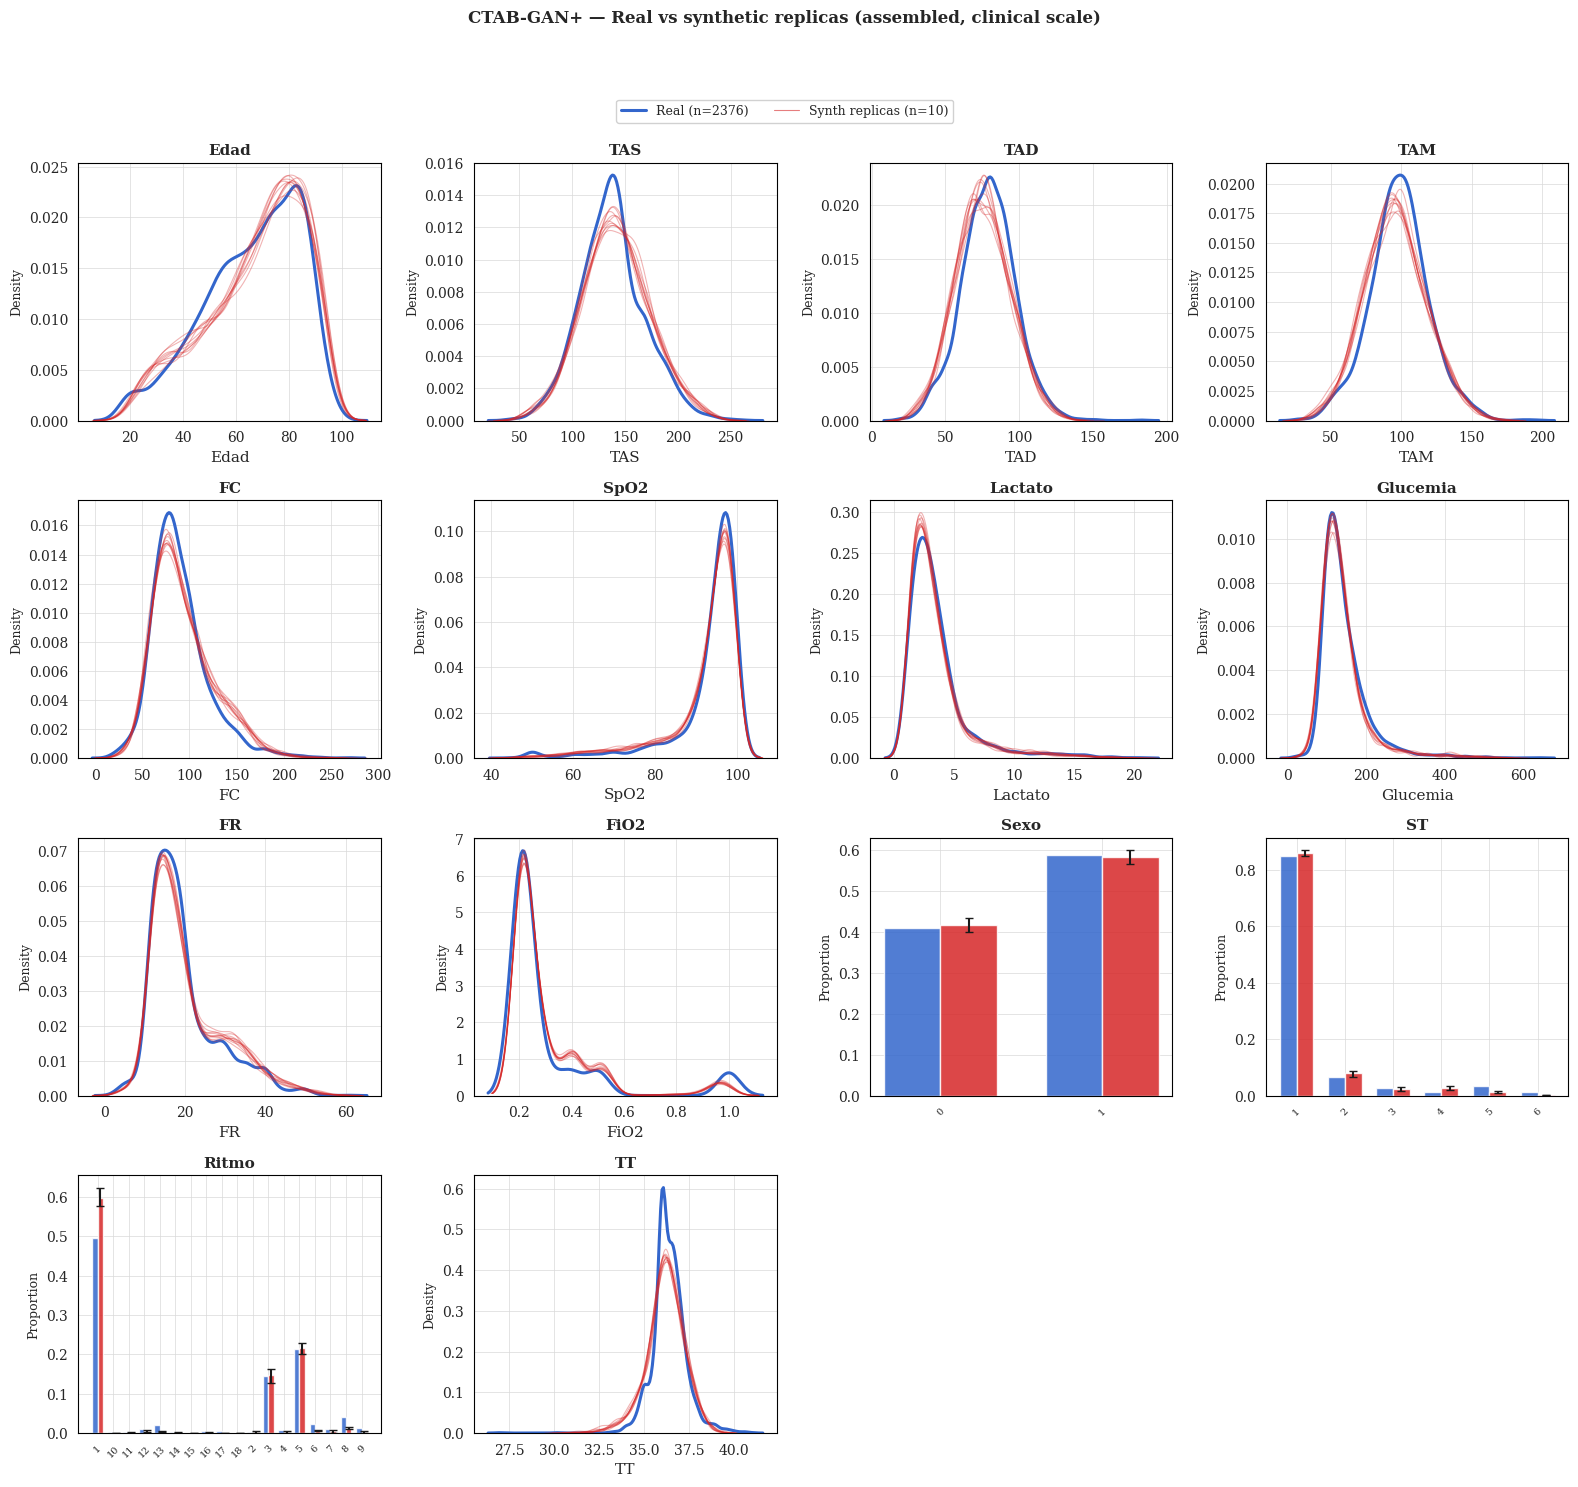

In [28]:
# ======================================================================
# 11 — Global distribution comparison (real vs N synthetic replicas)
#
# For each variable, one subplot with:
#   - Real distribution (dataset_FINAL.csv) as a thick reference line.
#   - N_SYNTH_DATASETS synthetic replicas overlaid as thin, transparent
#     traces. Visualises both average fidelity and inter-replica variance
#     in a single figure per generator.
#
# Assembled synthetic dataset = all 4 cohorts concatenated (clinical scale).
# ======================================================================

if RUN_PLOTS:
    if not os.path.exists(ORIG_PATH):
        raise FileNotFoundError(f"Original data not found: {ORIG_PATH}")
    df_orig = pd.read_csv(ORIG_PATH)

    PLOT_COLS_GLOBAL = [
        "Edad", "TAS", "TAD", "TAM", "FC", "SpO2",
        "Lactato", "Glucemia", "FR", "FiO2",
        "Sexo", "ST", "Ritmo", "TT",
    ]
    DISCRETE_SET = {"Sexo", "ST", "Ritmo", "GCS", "O2"}

    # Assemble each replica in clinical scale
    assembled_replicas = []
    for ds_idx in range(N_SYNTH_DATASETS):
        df_ds = pd.concat([
            inverse_transform(
                synthetic_cohort_full[name][ds_idx], metadata,
                cfg_minmax=CFG_MINMAX, cfg_log1p=CFG_LOG1P,
                cfg_ohe=CFG_OHE, cfg_drop_tam=CFG_DROP_TAM,
            )
            for name in cohorts.keys()
        ], ignore_index=True)
        assembled_replicas.append(df_ds)

    cols_to_plot = [c for c in PLOT_COLS_GLOBAL
                    if c in df_orig.columns
                    and all(c in d.columns for d in assembled_replicas)]

    n_cols_fig = 4
    n_rows_fig = (len(cols_to_plot) + n_cols_fig - 1) // n_cols_fig
    fig, axes = plt.subplots(
        n_rows_fig, n_cols_fig,
        figsize=(4 * n_cols_fig, 3.5 * n_rows_fig),
    )
    axes = axes.flatten()

    for i, col in enumerate(cols_to_plot):
        ax = axes[i]

        if col in DISCRETE_SET:
            rc = df_orig[col].astype(str).value_counts(normalize=True).sort_index()
            cats = list(rc.index)
            x = np.arange(len(cats))
            width = 0.35

            ax.bar(x - width/2, rc.values, width,
                   color=COLOUR_REAL, alpha=0.85,
                   label=f"Real (n={len(df_orig)})")

            rep_mat = np.vstack([
                d[col].astype(str).value_counts(normalize=True)
                 .reindex(cats, fill_value=0.0).values
                for d in assembled_replicas
            ])
            mean = rep_mat.mean(axis=0)
            lo   = rep_mat.min(axis=0)
            hi   = rep_mat.max(axis=0)

            ax.bar(x + width/2, mean, width,
                   color=COLOUR_SYNTH, alpha=0.85,
                   yerr=[mean - lo, hi - mean], capsize=3,
                   label=f"Synth mean \u00b1 range (n={N_SYNTH_DATASETS})")
            ax.set_xticks(x)
            ax.set_xticklabels(cats, rotation=45, fontsize=7)
            ax.set_ylabel("Proportion", fontsize=9)
        else:
            rv = pd.to_numeric(df_orig[col], errors="coerce").dropna()
            sns.kdeplot(rv, ax=ax, color=COLOUR_REAL,
                        linewidth=2.2, label=f"Real (n={len(rv)})")
            for d in assembled_replicas:
                sv = pd.to_numeric(d[col], errors="coerce").dropna()
                sns.kdeplot(sv, ax=ax, color=COLOUR_SYNTH,
                            linewidth=0.8, alpha=0.35)
            ax.plot([], [], color=COLOUR_SYNTH, linewidth=0.8, alpha=0.6,
                    label=f"Synth replicas (n={N_SYNTH_DATASETS})")
            ax.set_ylabel("Density", fontsize=9)

        ax.set_title(col, fontsize=11)
        if i == 0:
            ax.legend(fontsize=8, loc="best")

    for j in range(len(cols_to_plot), len(axes)):
        axes[j].set_visible(False)

    # Figure-level legend (picks up handles from the first subplot)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center",
                   bbox_to_anchor=(0.5, 1.00), ncol=2,
                   fontsize=9, frameon=True)
        axes[0].get_legend().remove()  # Remove per-axis legend if present

    fig.suptitle(
        "CTAB-GAN+ — Real vs synthetic replicas (assembled, clinical scale)",
        fontsize=12, fontweight="bold", y=1.06,
    )
    plt.tight_layout()
    fig_path = os.path.join(FIGS_OUT, "fig_replicas_vs_real.png")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()
    del df_orig

else:
    print("Skipping global comparison plot (RUN_PLOTS = False).")


## **12. Export synthetic datasets**

All output files are written to `GENERATION/DATASET_CTABGAN/` at clinical scale
(inverse-transformed from the **NB5** feature space). For each replica `dsXX`
(XX in 01–10):

| File | Description |
|------|-------------|
| `dsXX/dataset_SYNTH_CTABGAN.csv` | Assembled dataset (4 exclusive cohorts concatenated) |

Shared across all replicas:

| File | Description |
|------|-------------|
| `dataset_TEST.csv` | Real held-out test partitions (clinical scale, deduplicated) |
| `cohorts/cohort_<name>.csv` | Real training cohorts actually used to fit the generator (clinical scale) |
| `generation_metadata.json` | Generation parameters and cohort size summary |
| `figures/fig_replicas_vs_real.png` | Global distribution comparison |

This export layout keeps only the files that are operationally useful:
one assembled synthetic dataset per replica plus the real training/test references.
Separate endpoint CSVs are intentionally omitted.


In [29]:
# ======================================================================
# 12 — Export synthetic datasets
#
# Per replica → dsXX/ folder:
#   dataset_SYNTH_CTABGAN.csv  : all 4 cohorts concatenated (clinical scale)
#                                → NB8 fidelity evaluation / NB9 modeling
#
# Shared files (root of GEN_DIR):
#   dataset_TEST.csv           : deduplicated real test partitions (clinical scale)
#   cohorts/cohort_<name>.csv  : real training cohorts used to fit CTAB-GAN+
#
# Endpoint-specific CSV files are intentionally not exported because the
# assembled dataset already contains the three mortality targets.
# ======================================================================

exported_files: list[str] = []

def _inv(df_in, metadata):
    return inverse_transform(
        df_in, metadata,
        cfg_minmax=CFG_MINMAX, cfg_log1p=CFG_LOG1P,
        cfg_ohe=CFG_OHE, cfg_drop_tam=CFG_DROP_TAM,
    )

# -- 1. Per-replica assembled datasets (clinical scale) ----------------
for ds_idx in range(N_SYNTH_DATASETS):
    ds_label = f"ds{ds_idx + 1:02d}"
    ds_dir   = os.path.join(GEN_DIR, ds_label)
    os.makedirs(ds_dir, exist_ok=True)

    df_assembled = pd.concat(
        [_inv(synthetic_cohort_full[name][ds_idx], metadata) for name in cohorts.keys()],
        ignore_index=True,
    )[FINAL_EXPORT_COLS_CLINICAL]

    assembled_path = os.path.join(ds_dir, "dataset_SYNTH_CTABGAN.csv")
    df_assembled.to_csv(assembled_path, index=False)
    exported_files.append(assembled_path)
    print(f"✓ Replica {ds_label}: {assembled_path}  {df_assembled.shape}")

# -- 2. Real training cohorts used by the generator (clinical scale) ---
for cohort_name in cohorts.keys():
    safe_name = cohort_name.replace(" ", "_").replace(".", "")
    df_train  = _inv(cohort_splits[cohort_name]["train_full"], metadata)[FINAL_EXPORT_COLS_CLINICAL]
    path      = os.path.join(COHORTS_OUT, f"cohort_{safe_name}.csv")
    df_train.to_csv(path, index=False)
    exported_files.append(path)
    print(f"✓ Training cohort {cohort_name:<12}: {path}  {df_train.shape}")

# -- 3. Shared test set (clinical scale, deduplicated) -----------------
test_frames = [
    _inv(cohort_splits[c]["test_full"], metadata)
    for c in cohorts.keys()
    if len(cohort_splits[c]["test_full"]) > 0
]
df_test = pd.concat(test_frames, ignore_index=True).reset_index(drop=True)
df_test = df_test[FINAL_EXPORT_COLS_CLINICAL]
test_path = os.path.join(GEN_DIR, "dataset_TEST.csv")
df_test.to_csv(test_path, index=False)
exported_files.append(test_path)
print(f"✓ Test set: {test_path}  {df_test.shape}")

# -- Final output tree summary ----------------------------------------
# Shapes are derived from the already-exported assembled DataFrames;
# re-invoking inverse_transform here would be redundant.
_n_rows_per_ds = len(FINAL_EXPORT_COLS_CLINICAL)  # col count is fixed
_sample_df = pd.concat(
    [_inv(synthetic_cohort_full[name][0], metadata) for name in cohorts.keys()],
    ignore_index=True,
)[FINAL_EXPORT_COLS_CLINICAL]
_nrows, _ncols = _sample_df.shape
del _sample_df

print(f"\n{'═' * 84}")
print(f"  OUTPUT DIRECTORY: {GEN_DIR}")
print(f"{'─' * 84}")
print(f"  DATASET_CTABGAN/")
for ds_idx in range(N_SYNTH_DATASETS):
    ds_label = f"ds{ds_idx + 1:02d}"
    print(f"  ├── {ds_label}/dataset_SYNTH_CTABGAN.csv  ({_nrows:>5} × {_ncols})")
print(f"  ├── dataset_TEST.csv            ({df_test.shape[0]:>5} × {df_test.shape[1]})")
print(f"  ├── cohorts/")
for cohort_name in cohorts.keys():
    safe_name = cohort_name.replace(" ", "_").replace(".", "")
    print(f"  │   ├── cohort_{safe_name}.csv")
print(f"  ├── figures/fig_replicas_vs_real.png")
print(f"  └── generation_metadata.json")
print(f"{'═' * 84}")
print(f"✓ {len(exported_files)} file(s) exported successfully.")


✓ Replica ds01: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/ds01/dataset_SYNTH_CTABGAN.csv  (1781, 33)
✓ Replica ds02: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/ds02/dataset_SYNTH_CTABGAN.csv  (1781, 33)
✓ Replica ds03: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/ds03/dataset_SYNTH_CTABGAN.csv  (1781, 33)
✓ Replica ds04: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/ds04/dataset_SYNTH_CTABGAN.csv  (1781, 33)
✓ Replica ds05: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/ds05/dataset_SYNTH_CTABGAN.csv  (1781, 33)
✓ Replica ds06: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/ds06/dataset_SYNTH_CTABGAN.csv  (1781, 33)
✓ Replica ds07: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/ds07/dataset_SYNTH_CTABGAN.csv  (1781, 33)
✓ Replica ds08: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/ds08/datase

In [30]:
# ======================================================================
# section 12.1 — Export generation metadata (NB8 / NB9 compatibility)
# ======================================================================
from datetime import datetime as _dt

# ── Cohort size summary ───────────────────────────────────────────────
_cohort_sizes = {
    name: {
        "n_full":  int(len(info["df_full"])),
        "n_train": int(cohort_splits[name]["sizes"]["train"]),
        "n_test":  int(cohort_splits[name]["sizes"]["test"]),
        "n_synth": int(info.get("n_synth", 0)),
    }
    for name, info in cohorts.items()
}


generation_metadata = {
    "generator":   "CTAB-GAN+",
    "notebook":    "NB6",
    "version":     "V7_4",
    "source_file": "dataset_FINAL.csv",
    "environment": collect_environment_metadata(),
    "export_layout": {
        "version": "per_replica_assembled_plus_training_cohorts",
        "files_per_replica": [
            "dataset_SYNTH_CTABGAN.csv",
        ],
        "shared_files": [
            "dataset_TEST.csv",
            "cohorts/cohort_<name>.csv",
        ],
        "cohort_files_role": "real training cohorts used to fit CTAB-GAN+",
    },
    "type_map": {
        "continuous_columns":  list(CONTINUOUS_COLS),
        "binary_columns":      list(BINARY_COLS),
        "categorical_columns": list(ORIGINAL_CATEGORICAL_COLS),
        "ordinal_columns":     list(ORDINAL_COLS),
        "outcome_columns":     list(OUTCOMES),
    },
    "split": {
        "random_seed": int(RANDOM_SEED),
        "train_ratio": float(TRAIN_RATIO),
        "min_size":    int(SPLIT_MIN_SIZE),
    },
    "survivors": {
        "cap_applied": bool(surv_capped),
        "cap_n":       int(SURVIVOR_TRAIN_MAX_N) if surv_capped else None,
        "cap_seed":    int(RANDOM_SEED),
        "n_full":      int(n_surv_full),
        "n_used":      int(len(cohorts["survivors"]["df_full"])),
    },
    "cohort_sizes": _cohort_sizes,
    "replicas": {
        "n_datasets": int(N_SYNTH_DATASETS),
        "seeds":      [int(s) for s in REPLICA_SEEDS[:N_SYNTH_DATASETS]],
        "seed_strategy": "numpy.random.SeedSequence(RANDOM_SEED).spawn(N_SYNTH_DATASETS)",
    },
    "generation_timestamp": _dt.now().isoformat(timespec="seconds"),
}

meta_path = os.path.join(GEN_DIR, "generation_metadata.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(generation_metadata, f, indent=2, default=str)

print(f"Metadata written: {meta_path}")
print(f"  version      : {generation_metadata['version']}")
print(f"  export_layout: {generation_metadata['export_layout']['version']}")
print(f"  files/replica: {generation_metadata['export_layout']['files_per_replica']}")
print(f"  shared files : {generation_metadata['export_layout']['shared_files']}")


Metadata written: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN/generation_metadata.json
  version      : V7_4
  export_layout: per_replica_assembled_plus_training_cohorts
  files/replica: ['dataset_SYNTH_CTABGAN.csv']
  shared files : ['dataset_TEST.csv', 'cohorts/cohort_<name>.csv']


## **13. Cleanup and final summary**

Temporary cohort CSV files written to `cohorts_temp/` during training are
removed; these files contained only the training partitions in **NB5** encoded
space and are no longer needed after **section 7** completes.

A final summary confirms the execution mode, the number of replicas generated
per cohort, and the output directory path.


In [31]:
# ── Remove temporary cohort CSVs ───────────────────────────────────────
import shutil
if os.path.isdir(COHORT_DIR):
    shutil.rmtree(COHORT_DIR)
    print(f"\u2713 Removed temp directory: {COHORT_DIR}")

# ── Final session summary ─────────────────────────────────────────────
print(f"\n{'=' * 76}")
print(f"  NB6 — CTAB-GAN+ GENERATION COMPLETE")
print(f"{'=' * 76}")
print(f"  Device mode        : {EXECUTION_MODE} ({DEVICE_LABEL})")
print(f"  Replicas generated : {N_SYNTH_DATASETS}")
print("  Cohorts (replica 1):")
for name in COHORT_TRAINING_ORDER:
    n = len(synthetic_cohorts[name][0])
    print(f"    {name:<12}: {n:>5} synthetic rows")
print(f"  Output directory   : {GEN_DIR}")
print(f"{'=' * 76}")

os.remove('/content/dataset_PREGEN.csv')
os.remove('/content/pregen_metadata.json')
os.remove ('/content/dataset_FINAL.csv')

✓ Removed temp directory: /content/cohorts_temp

  NB6 — CTAB-GAN+ GENERATION COMPLETE
  Device mode        : gpu_sequential (GPU)
  Replicas generated : 10
  Cohorts (replica 1):
    survivors   :  1586 synthetic rows
    Mort. 7D    :    44 synthetic rows
    Mort. 2D    :    85 synthetic rows
    Mort. 30D   :    66 synthetic rows
  Output directory   : /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_CTABGAN
